# Introduction à CKKS

Jocelyn Maury

jocelyn.maury@univ-st-etienne.fr

Ce jupyter notebook à pour but d'expliquer les bases de CKKS. CKKS est un schéma cryptographique qui permet de réaliser des opérations (addition et multiplication) sur des valeurs chiffrées qui aboutissent approximativement au même résultat une fois le résultat déchiffré que si les opérations avaient été effectuées sur les données en clair. 

Ce notebook est basé sur plusieurs ressources, et fortement basé sur les deux ressource suivante : https://arxiv.org/pdf/2503.05136 et https://eprint.iacr.org/2016/421.pdf 

# Encodage

La sécurité de CKKS est basée sur le problème de "RLWE". Ce problème repose sur le présupposé qu'il est très dur de trouver m une fois chiffré de la façon suivante : 
$$m_i = - A_i \times S + m_i + e_i$$
avec $m_i$ un message, $A_i$ un polynôme public tiré de façon aléatoire, $S$ un polynôme privé aléatoire à coefficient compris dans l'ensemble {-1, 0, 1} et $e_i$ un petit bruit gaussien aléatoire. Pour chiffrer un message de cette façon, nous avons besoin que notre message soit un polynôme car le problème vis dans l'anneau des polynômes cyclotomiques à coefficents entier : $\mathbf{Z}[X]/X^N +1$ avec $N$ une puissance de 2, pour des raisons de sécurité.   

Cependant, dans la plupart des application, les valeurs d'entrées sur lesquelles nous souhaitons réaliser des opérations ne sont pas directement des polynômes : Elles peuvent être des réels ou des complexes. Donc nous cherchons une façon de transformer nos complexes en polynômes cyclotomiques à coefficient réels. Il faut que cette transformation soit bijective et homomorphe : Nous cherchons donc un isomoprhisme $\mathbb{C}^N \to \mathbf{Z}[X]/X^N +1$. 

Le théorème d'interpolation de Lagrange nous indique qu'à partir de couples de points $(x_1, y_1), (x_2, y_2)...(x_n, y_n)$ il y a un seul polynôme de degré maximum $n - 1$ qui passe par tout ces point. Ainsi, en prenant les points d'entrées noté $y$ et en définissant un ensemble de points d'évaluation de ces points d'entrées noté $x$, nous pouvons calculer les coefficients du polynôme unique qui passe par tout ces points, noté $c$. Matriciellement,  nous pouvons poser que les points d'évaluations multipliés par les coefficients du polynôme unique nous donnerons un ensemble de points tel que 
$$ \begin{array}{cc}
\begin{pmatrix}  
1 & x_{1} & x_{1}^{2} & \cdots & x_{1}^{n - 1} \\  
1 & x_{2} & x_{2}^{2} & \cdots & x_{2}^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & x_{n} & x_{n}^{2} & \cdots & x_{n}^{n - 1}
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
\vdots \\
c_n
\end{pmatrix} 
=
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{pmatrix} \\ \\
\Rightarrow X \cdot c = y
\end{array}
$$
Nous, nous disposerons du vecteur d'entrée $y$ et des points d'évaluations $X$ et nous chercherons à calculer les coefficients du polynômes uniques passant par tout les couples de points $(x,y)$. Cela revient à résoudre l'équation suivante : 
$$X^{-1} \cdot  y = c$$
soit 
$$\begin{pmatrix}  
1 & x_{1} & x_{1}^{2} & \cdots & x_{1}^{n - 1} \\  
1 & x_{2} & x_{2}^{2} & \cdots & x_{2}^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & x_{n} & x_{n}^{2} & \cdots & x_{n}^{n - 1}
\end{pmatrix} ^{-1}
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{pmatrix}
=
\begin{pmatrix}
c_1 \\
c_2 \\
\vdots \\
c_n
\end{pmatrix} 
$$ 
Il faut donc s'assurer que la matrice $X$ soit toujours inversible. Comme elle est constituée pour chaque ligne d'un $x_i$ qui augmente en puissance de colonne en colonne, il s'agit en fait d'une matrice de Vandermonde :


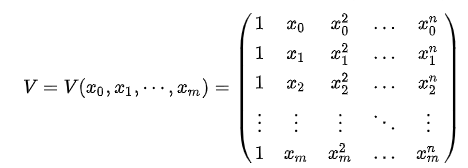

https://en.wikipedia.org/wiki/Vandermonde_matrix

Une matrice de Vandermonde est toujours inversible si les $\alpha_i$ sont tous distincts deux à deux. Ainsi, avec la contrainte de choisir des $x_i$ tous distincts deux à deux, nous nous assurons que notre matrice $X$, que nous nommerons à présent $V$ est toujours inversible. Il nous faut nous intéresser à la nature des $x_i$ qui compose $V$. Comme nous travaillons dans $\mathbf{Z}[X]/X^N+1$, cela signifie que les $x_i$ de notre matrice $V$ doivent respecter la relation $x_i^n +1 =0$. Donc on a : 
$$ \begin{array}{cc}\\
x_{i}^{n} +1=0 \\
x_i^n = -1 \\
x^{2n}_i = (-1)^2 = 1
\end{array}
$$
Donc les $x_i^n = -1$ font partie de l'ensemble des $2n$ ième racines unités. 

https://e.math.cornell.edu/people/belk/numbertheory/CyclotomicPolynomials.pdf

https://en.wikipedia.org/wiki/Cyclotomic_polynomial

De plus, pour trouver les solutions à $x^{2n}_i = 1$, nous pouvons poser
$$\begin{array}{cc}
x^{2n}_i = 1 \\
(x^{n} + 1)(x^{n} - 1) = 0
\end{array}
$$
Nous connaissons déjà les solutions à $x^{2n}_i = 1$, ce sont les $2n$e racines unités, sachant que classiquement, nous avons les $n$e racines unités représentées par l'ensemble de complexes suivant : $\{ \zeta^N = 1 : \zeta = e^{2k \pi i /n }, 0 \leq k < n \}$, donc les $2n$e racines unités sont notées $\{ \zeta^{2N} = 1 : \zeta = e^{2k \pi i / 2N} = e^{k \pi i / n}, 0 \leq k < 2N  \}$. 
Nous, nous cherchons l'ensemble de solutions à $(x^n + 1) = 0$ et nous connaissons les solutions à $X^{2n} - 1 = 0$ ce qui revient à l'ensemble des solutions de $(x^n +1)(x^n -1) = 0$. Donc si nous arrivons à déterminer l'ensemble des solutions de $(x^n -1) = 0$ alors nous pourrons faire :  
$$
\begin{array}{cc}
\{\text{2ne racines unités}\} - \{\text{solutions à }(x^n - 1 = 0)\} = \{\text{solutions à }(x^n + 1 = 0) \}
\end{array}
$$
Donc nous cherchons 
$$
\begin{array}{cc}
x^n - 1 = 0 \\
x^n = 1  \\
\Rightarrow \{\zeta'^n =1 : \zeta' = e^{2k \pi i / n}, 0 \leq k' < n\}
\end{array}
$$
Les solutions à $(x^n + 1 = 0)$ sont les $2ne$ racines unités qui ne sont pas solutions à $(x^n - 1 = 0)$ donc nous cherchons 
$$
\begin{array}{cc}
\{ \zeta^{2N} = 1 : \zeta = e^{2k \pi i / 2N} = e^{k \pi i / n}, 0 \leq k < 2N  \} \neq \{\zeta'^n =1 : \zeta' = e^{2k' \pi i / n}, 0 \leq k' < n\} \\
\zeta = e^{k \pi i /n}, \zeta' = e^{2k' \pi i /n}  \\
\zeta = \zeta' \text{ ssi } k = 2k', \text{ soit } \frac{k}{2} = k'
\end{array}
$$
Comme $k,k' \in \mathbb{Z}$ alors $k$ doit être un multiple de $2$ (un nombre pair). A l'inverse, pour tout les cas où $k$ est impair, ce n'est plus solution à $(x^n =1)$ et donc solution à $(x^n = -1)$. Ainsi, les racines de $(x^n = -1)$ sont les $n$ complexes distincts suivants : 
$$
\begin {array}{cc}
\{\zeta = e^k \pi i /n, 0 \leq k < 2N, 2 \nmid k \} \\
= \omega, \omega^3, \omega^5,\dots, w^{2n -1}
\end{array}
$$


Donc nous pouvons construire une matrice $V$ avec tout les $x_i$ distincts et qui respectent $x_i^n +1 =0$.
$$\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix}
$$

Il nous faut vérifier la bijectivité de l'application $V$. En effet, même si le théorème d'interpolation de Lagrange semble nous donner la bijectivité, il faut vérifier que l'on en respecte le cadre : 

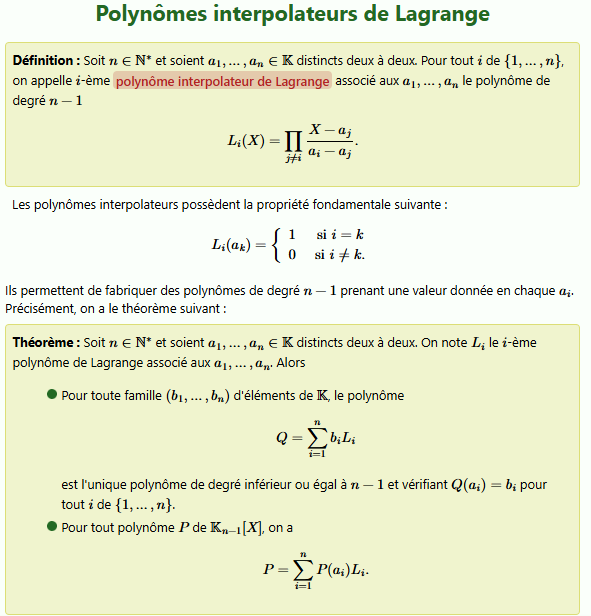

https://www.bibmath.net/dico/index.php?action=affiche&quoi=./p/polynomelagrange.html

Pour plus de lisibilité, nous allons nous servir de la propriété suivante pour notre matrice de Vandermonde $V^{-1}= \frac{V^T \cdot \ I^R_n}{n}$. 

Tout d'abord : 
$$
\begin{array}{cc}
V \cdot V^T = 
\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix}
\cdot
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
\omega & \omega^3 & \omega^5 & \cdots & \omega^{2n-1} \\
(\omega)^2 & (\omega^3)^2 & (\omega^5)^2 & \cdots & (\omega^{2n-1})^2 \\
\vdots & & \ddots & & \vdots \\
(\omega)^{n-1} & (\omega^3)^{n-1} & (\omega^5)^{n-1} & \cdots & (\omega^{2n-1})^{n-1}
\end{pmatrix} \\ \\
=
\begin{pmatrix}
\sum_{k=0}^{n-1}\omega^{2k} & \sum_{k=0}^{n-1}\omega^{4k} & \sum_{k=0}^{n-1}\omega^{6k} & \cdots & \sum_{k=0}^{n-1}\omega^{2nk} \\
\sum_{k=0}^{n-1}\omega^{4k} & \sum_{k=0}^{n-1}\omega^{6k} & \sum_{k=0}^{n-1}\omega^{8k} & \cdots & \sum_{k=0}^{n-1}\omega^{2k(n+1)} \\
\sum_{k=0}^{n-1}\omega^{6k} & \sum_{k=0}^{n-1}\omega^{8k} &\sum_{k=0}^{n-1}\omega^{10k} & \cdots & \sum_{k=0}^{n-1}\omega^{2k(n+2)} \\
\vdots & & \ddots & & \vdots \\
\sum_{k=0}^{n-1}\omega^{2nk} & \sum_{k=0}^{n-1}\omega^{2(n+1)k}  &  \sum_{k=0}^{n-1}\omega^{2(n+2)k} & \cdots &  \sum_{k=0}^{n-1}\omega^{2(n+n-1)k}
\end{pmatrix}
\end{array}
$$
Nous pouvons voir que tout les éléments antidiagonales sont $\sum_{k=0}^{n-1}\omega^{2nk}$ donc : 
$$\begin{array}{cc}
\sum_{k=0}^{n-1}\omega^{2nk} \\ 
= \sum_{k=0}^{n-1} e^{(i \pi /n)2nk} \\
= \sum_{k=0}^{n-1} e^{2 i \pi k} \\
= \sum_{k=0}^{n-1} (cos(2 \pi k) + i sin(2 \pi k)) \\
= \sum_{k=0}^{n-1} (1 + 0) = n
\end{array}
$$
Donc les éléments anti-diagonaux sont uniquement $n$. Pour les autres éléments $\sum_{i=0}^{n-1} \omega^{2k}, \sum_{i=0}^{n-1} \omega^{4k}, \dots, \sum_{i=0}^{n-1} \omega^{2(2n-1)k}$ nous pouvons identifier qu'ils sont tous de la forme $\sum_{k=0}^{n-1} \omega^{2(m)k}$ avec $1 \leq m < n-1$. Nous avons grâce à la formule de la somme géométrique : 
$$
\begin{array}{cc}
S_n = \sum_{i=0}^{n-1} x^i = 1 + x + x^2 + \dots + x^{n-1} \\
x \cdot S_n = x + x^2 + x^3 + \dots + x^n \\
x \cdot S_n - S_n = (x + x^2 + x^3 + \dots + x^n) - (1 + x + x^2 + \dots + x^{n-1}) = x^n - 1 \\
S_n \cdot(x - 1) = x^n -1 \\
S_n = \frac{x^n -1}{x - 1} \text{tant que }x \neq 1 \\
\text{Donc } S_n = \sum_{i=0}^{n-1} x^i = 1 + x + x^2 + \dots + x^{n-1} = \frac{x^n -1}{x - 1}
\end{array}
$$

Grâce à cette formule on a : 
$$
\begin{array}{cc}
\sum_{k=0}^{n-1} \omega^{2(m)k} = \frac{\omega^{(2m)n} - 1}{\omega^{2m} - 1} \\
= \frac{\omega^{(2n)m} - 1}{\omega^{2m} - 1} \\
= \frac{1 - 1}{\omega^{2m} - 1} = 0 \text{ tant que } 0 \leq m < n
\end{array}
$$
Ainsi, nous pouvons réécrire l'inverse comme : 
$$V \cdot V^T = 
\begin{pmatrix}
0 & \cdots & 0 & 0 & n \\
0 & \cdots & 0 & n & 0 \\
0 & \cdots & n & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
n & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
 = n \cdot 
\begin{pmatrix}
0 & \cdots & 0 & 0 & 1 \\
0 & \cdots & 0 & 1 & 0 \\
0 & \cdots & 1 & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
1 & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
= n \cdot I^R_n
$$
avec $I^R_n$ la matrice de renversement (elle a pour effet d'échanger l'odre des colonnes, la première passe dernière, la deuxième passe avant dernière...).
A partir de ce résultat : 
$$
\begin{array}{cc}
V \cdot V^T = n \cdot I^R_n \\
V^{-1} \cdot V \cdot V^T = V^{-1} \cdot n \cdot I^R_n \\
V^T = V^{-1} \cdot n \cdot I^R_n \\
\frac{V^T \cdot I^R_n}{n} = V^{-1}
\end{array}
$$


A partir de là, nous pouvons étudier comment seront calculés les coefficients des polynômes, pour voir les contraintes nécessaires pour que les parties imaginaires s'annulent : 
$$
\begin{array}{cc}
V^{-1} \cdot y  = c  \\ \\
\frac{V^T \cdot I^R_n}{n} \cdot y \propto V^T \cdot I^R_n \cdot y \\ \\
\propto 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
\omega & \omega^3 & \omega^5 & \cdots & \omega^{2n-1} \\
(\omega)^2 & (\omega^3)^2 & (\omega^5)^2 & \cdots & (\omega^{2n-1})^2 \\
\vdots & & \ddots & & \vdots \\
(\omega)^{n-1} & (\omega^3)^{n-1} & (\omega^5)^{n-1} & \cdots & (\omega^{2n-1})^{n-1}
\end{pmatrix}
\cdot 
\begin{pmatrix}
0 & \cdots & 0 & 0 & 1 \\
0 & \cdots & 0 & 1 & 0 \\
0 & \cdots & 1 & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
1 & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
\cdot 
\begin{pmatrix}
y_1 \\
y_2 \\
y_3 \\
\vdots \\
y_n
\end{pmatrix} \\ \\
=   
\begin{pmatrix}
1 & 1 & \cdots & 1 & 1 \\
\omega^{2n-1}  & \omega^{2n-3} & \cdots & \omega^3 & \omega \\
(\omega^{2n-1})^2  & (\omega^{2n-3})^2 & \cdots &  (\omega^3)^2 & (\omega)^2  \\
\vdots & & \ddots & & \vdots \\
(\omega^{2n-1})^{n-1} & (\omega^{2n-3})^{n-1} &  \cdots &  (\omega^3)^{n-1} &  (\omega)^{n-1}
\end{pmatrix}
\cdot 
\begin{pmatrix}
y_1 \\
y_2 \\
y_3 \\
\vdots \\
y_n
\end{pmatrix} \\
= \begin{pmatrix}
\sum_{i=1}^{n}y_i \\
\sum_{i=1}^{n}y_i \omega^{2n - (2i-1)} \\
\sum_{i=1}^{n}y_i \omega^{(2n - (2i-1))^{2}} \\
\vdots \\
\sum_{i=1}^{n}y_i \omega^{(2n - (2i-1))^{n-1}} \\
\end{pmatrix}
\end{array}
$$
Ainsi, nous avons la forme explicite de nos coefficients à un facteur prêt Nous pouvons voir qu'il s'agit de combinaisons linéaires entre nos valeurs en entrées et les points d'évaluation. En entrée, nous avons des $y_i \in \mathbb{C}$ donc  $\sum_{i=0}^{n-1}y_i \in \mathbb{C}$ sauf si les valeurs imaginaires se compensent entre elles. De plus, le produit pondéré des points d'évaluation $\omega_i$ donnera aussi un résultat dans $\mathbb{C}$ sauf si les parties imaginaires des points d'évaluation se compensent entre elles après pondération par les $y_i$. Sans cette annulation de la partie imaginaire, notre vecteur de coefficients de polynôme $c^N \in \mathbf{C}[X]/X^N +1$ et non $\mathbf{Z}[X]/X^N + 1$.
Donc nous voulons nous assurer que 
- $\sum_{i=1}^{n}y_i = a + 0i$ avec $a \in \mathbb{R}$.
- $\sum_{i=1}^{n}y_i \omega^{(2n - (2i-1))b} = a + 0i$ avec $a \in \mathbb{R}, 1 \leq b < n$.

Comme nous voulons que les valeurs du vecteur d'entrée soit à choix libre, il faut construire un $y'$, basé sur $y$ qui respecte $\sum_{i=0}^{n-1}y_i = a + 0i$. Une façon efficace de faire cela est de prendre $y' = (y_1, y_2,\dots, y_n ) | (\overline{y_1}, \overline{y_2}, \dots, \overline{y_n}) = (y_1, y_2,\dots, y_n, \overline{y_1}, \overline{y_2}, \dots, \overline{y_n} ) = (y | \overline{y})$  soit la concaténation de $y$ avec son conjugué. Ainsi, $\sum_{i=0}^{n-1}{y'_i} = a + 0i$.

Pour le deuxième cas, nous avons une somme de produit pondéré, sachant que les $y'$ s'annulent leur partie imaginaire entre eux. Il faudrait donc une symétrie de conjugués sur les $\omega$ pour s'assurer que les parties imaginaires s'annulent bien : 
$$
\begin{array}{cc}
\sum_{i=1}^{n}y'_i \omega^{(2n - (2i-1))b} \\ 
= y_1\omega^{(2n -1)b} + \dots + y_n\omega^{(2n-(n-1))b} + \overline{y_1}\overline{\omega^{(2n-(2n+1)b}} + \dots + \overline{y_n}\overline{\omega^{(2n-1)b}}
\end{array}
$$
De cette façon, les parties imaginaires s'annulent entre elles deux à deux. 
Comme le choix des $\omega$ n'est pas arbitraire, il faut vérifier qu'ils respectent la relation : $\omega_i = \overline{\omega_{2n - i}}$, i.e : 
$$
\begin{array}{cc}
\omega_1 = \overline{\omega_{2n-1}} \\
\omega_3 = \overline{\omega_{2n-3}} \\
\omega_5 = \overline{\omega_{2n-5}} \\
\dots \\
\omega_{n-1} = \overline{\omega_{n+1}} \\
\dots \\
\omega_{2n-1} = \overline{\omega_{1}} \\
\end{array}
$$
Cette relation est vraie et peut être dérivée directement à partir de la formule d'Euler. 
Grâce à cette relation, nous savons que nous avons bien
$$
\begin{array}{cc}
\sum_{i=1}^{n}y'_i \omega^{(2n - (2i-1))b} \\ 
= y_1\omega^{(2n -1)b} + \dots + y_n\omega^{(2n-(n-1))b} + \overline{y_1}\overline{\omega^{(2n-(2n+1))b}} + \dots + \overline{y_n}\overline{\omega^{(2n-1)b}}
\end{array}
$$
Cependant, nous pouvons voir que nous avons $y_n \times \omega^{(2n - (n-1))b} + \overline{y_1} \times \overline{\omega^{(2n - (2n+1))b}}$ . Les parties imaginaires ne sont pas forcées de s'annuler car nous les $y_i$ ne sont pas alignés avec leur $\omega$. Nous souhaitons avoir $y_n \times \omega^{(2n - (n-1))b} + \overline{y_n} \times \overline{\omega^{(2n - (2n+1))b}}$, ce qui nous donnerait dans la somme total : 
$$
\begin{array}{cc}
\sum_{i=1}^{n}y'_i \omega^{(2n - (2i-1))b} \\ 
= y_1\omega^{(2n -1)b} + \dots + y_n\omega^{(2n-(n-1))b} + \overline{y_n}\overline{\omega^{(2n-(2n+1))b}} + \dots + \overline{y_1}\overline{\omega^{(2n -1)b}}
\end{array}
$$

Donc nous devons modifier $y' = (y_1, \dots, y_n, \overline{y_1}, \dots, \overline{y_n}) =(y | \overline{y})$ en $y' = (y_1, \dots, y_n, \overline{y_n}, \dots, \overline{y_1}) = (y | \text{ reverse order}(\overline{y}))$. En construisant $y'$ de cette façon et grâce à la structure particulière de $V$ nous avons donc $\frac{V^T \cdot I^R_N}{n} \cdot y = c \in \mathbb{R}^N$. 

Nous ne faisons plus $\mathbf{R}[X]/X^N +1 \to \mathbb{C}^N$ car il était impossible d'avoir bijectivité (bijectivité uniquement possible pour $\mathbf{C}[X]/X^N +1 \to \mathbb{C}^N$). A la place nous faisons $\mathbf{R}[X]/X^N +1 \to \hat{\mathbb{C}}^N \to \mathbb{C}^{N/2}$. Nous avons réduit notre espace d'entrée par deux.  Cependant, nous ne somme toujours pas dans $\mathbf{Z}[]/X^N +1$. Nous réglerons ce problème plus tard. 
Maintenant que nous avons la bijectivité, nous avons besoin de vérifier que $V$ est aussi homomorphique pour avoir isomorphisme entre l'anneau $\mathbf{R}[X]/X^N +1$ et $\mathbb{C}^{N/2}$. Pour cela, il faut que : 
- $V(c + d) = Vc + Vd$, vérifié par linéarité de matrice 
- $V(c * d) = Vc ? Vd$ avec $?$ une opération multiplicative qui permet à $C^{N/2}$ muni de l'addition et $?$ d'être un anneau. L'opération $*$ désigne la convolution, qui correspond à la multiplication de polynôme. 
Posons deux polynômes $c(X) = \sum_{i=0}^{n-1} c_i X^i;  \ d(X) = \sum_{j=0}^{n-1} d_j X^j$. La multiplication des deux polynômes nous donne : 
$$\begin{array}{cc}\\
c(X)d(X) \\
= (\sum_{i=0}^{n-1} c_i X^i) (\sum_{j=0}^{n-1} d_j X^j) \\
= \sum_{i=0}^{n-1}\sum_{j=0}^{n-1}c_i d_j X^{i+j}
\end{array}
$$
Pour simplifier la démonstration, nous pouvons regarder ce qu'il se passe au niveau d'une composante de $(V(c * d))_k$ qui consiste donc à évaluer le polynômes en la composante $\omega_k$ :
$$\begin{array} {cc}
(V(c * d))_k \\
= (\sum_{i=0}^{n-1} c_i \omega^i_k) (\sum_{j=0}^{n-1} d_j \omega^j_k) \\
= (Vc)_k )(Vd)_k
\end{array}$$
De cette façon le vecteur $V(c * d)$ est constitué des produits suivants : 
$$\begin{pmatrix}
(Vc)_0(Vd)_0 \\
(Vc)_1(Vd)_1 \\
\vdots \\
(Vc)_{n-1}(Vd)_{n-1} \\
\end{pmatrix} = Vc \ \odot \ Vd$$
Ce qui nous donne : 
$$V(c * d) = Vc \ \odot Vd$$
Donc on a un isomorphisme d'anneau $R[X]/X^N +1 \to C^{N/2}$ grâce à $V$ : 
$$\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
c_3 \\
\vdots \\
c_n
\end{pmatrix} 
= 
\begin{pmatrix}
y_1 \\
y_2 \\
y_3 \\
\vdots \\
y_n
\end{pmatrix}
$$
soit 
$$Vc = y$$
et donc 
$$V^{-1}y = c$$
C'est sur cet isomorphisme que repose l'encodage de CKKS. Nous prenons en entrée un vecteur de complexes $y$ puis nous le concaténons à son conjugué, pour ensuite l'évaluer en les racines unités pour obtenir les coefficients du polynôme qui servira de vecteur encodé. Pour passer dans l'espace $Z[X]/X^N +1$ nous allons arrondir les coefficient à l'entier le plus proche. Si nous nous contentons de directement arrondir, nous allons perdre énormément de précision. Pour garder le maximum de précision possible, nous multiplions au préalable nos coefficient par un facteur $\Delta$ : $\tilde{c} = \lfloor \Delta c \rceil$. Au final, nous opérons les opérations d'encodage et de décodage suivantes : 
$$
y \in \mathbb{C^{N/2}} \to y' \in \hat{\mathbb{C}}^N \to c \in \mathbf{R}[X]/X^N +1 \to \tilde{c} \in \mathbf{Z}[X]/X^N +1 \to \tilde{y'} \in \hat{\mathbb{C}}^N \to \tilde{y} \in \mathbb{C^{N/2}}
$$

Pour garder les calculs les plus simple possible, nous allons travailler avec des coefficients modulo $t$ pour garder la taille des coefficient plus petit qu'une certaine limite. Pour ce faire, nous allons travailler dans $\mathbf{Z}_t[X]/X^N + 1$. Pour choisir le modulus $t$ nous devons prendre en compte plusieurs facteurs : 
- Nombre d'opérations souhaitées 
- Tailles des messages en entrées 
- Bruit tolérables 
- Cohérent avec la NTT/FTT pour la multiplication optimisée dans $Z[X]/X^N +1$. 

Pour la taille des messages d'entrées, nous devons nous assurer que $\Delta m$ n'overflow pas, donc $\Delta m < t$. 
Les opérations possibles sont l'addition et la multiplication. Donc nous aimerions nous assurer que nous pouvons au moins faire une multiplication ou une addition de deux messages encodés. Evidemment, cela dépend directement de la taille des messages en entrée et de leur taille une fois encodés. Si nous définissons le message de taille maximum $m_{max}$ alors l'addition prend une taille $\Delta m_{max} + \Delta m_{max}$ et la multiplication $\Delta m_{max} \cdot \Delta m_{max}$. En supposant que $\Delta m_{max} \geq 2$  alors $| \Delta m_{max} \cdot \Delta m_{max} | \geq | \Delta m_{max} + \Delta m_{max} |$. Donc il faut choisir $t \geq | \Delta m_{max} \cdot \Delta m_{max} |$. Comme nous travaillons avec des polynômes, il faut s'assurer en réalité qu'aucun des coefficient des polynômes ne soit plus grand que $t$. Posons $|a_i| < B$ pour $a_i$ les coefficients de $\Delta m_{max}$. Ainsi $| \Delta m_{max} \cdot \Delta m_{max} | \leq NB^2$ avec $N$ le degré du polynôme.  Donc il faut au moins prendre $t \geq NB^2$. 

Par ailleurs, nous verrons ultérieurement que CKKS est un schéma lourd computationnellement. Dans l'objectif d'optimiser ce coût, la multiplication est optimisé via Number Theory Transform et Fast Fourrier Transform. Nous verrons cela plus en détail ultérieurement. 

Par ailleurs, nous verrons ultérieurement que CKKS est un schéma lourd computationnellement. Dans l'objectif d'optimisé ce coût, la multiplication est optimisé via Fast Fourrier Transform. Son but est de réduire la complexité de la multiplication de polynôme. En effet, nos données encodés vivent dans l'anneau des polynôme donc les additions et multiplications seront des additions et des multiplications de polynômes. La façon basique d'effectuer une multiplication de polynôme est : 
$$ \begin{array}{cc}
A(X) = \sum_{i=0}^{n-1} a_i X^i, B(X) = \sum_{j=0}^{n-1} b_j X^j \\
C(X) = A(X) \cdot B(X) = (\sum_{i=0}^{n-1} a_i X^i)(\sum_{j=0}^{n-1} b_j X^j) = \sum_{i=0}^{n-1} \sum_{j=0}^{n-1} a_i b_j X^{i +j}
\end{array}
$$
Cette multiplication peut être représenté par un calcul matriciel : 
$$
\begin{pmatrix}
b_0 & 0 & 0 & \cdots & 0 & 0 \\
b_1 & b_0 & 0 & \cdots & 0 & 0 \\
b_2 & b_1 & b_0 & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
b_{n-2} & b_{n-3} & b_{n-4} & \cdots & b_0 & 0 \\
b_{n-1} & b_{n-2} & b_{n-3} & \cdots & b_{1} & b_{0} \\
0 & b_{n-1} & b_{n-2} & \cdots & b_2 & b_1 \\
0 & 0 & b_{n-1} & \cdots & b_3 & b_2 \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & 0 & b_{n-1} & b_{n-2} \\
0 & 0 & 0 & \cdots & 0 & b_{n-1}
\end{pmatrix}
\cdot 
\begin{pmatrix}
a_0 \\
a_1 \\
a_2 \\
\vdots \\
a_{n-2} \\
a_{n-1}
\end{pmatrix}
= 
\begin{pmatrix}
b_0a_0 \\
b_1a_0 + b_0a_1 \\
b_2a_0 + b_1a_1 + b_0a_2 \\
\vdots \\
b_{n-1}a_0 + b_{n-2}a_1 + \cdots + b_0a_{n-1} \\ 
\vdots \\
b_{n-1}a_{n-2} + b_{n-2}a_{n-1} \\ 
b_{n-1}a_{n-1}
\end{pmatrix}
$$
Nous pouvons identifier que la la matrice contenant les coefficient $b_i$ est une matrice de Toeplitz que nous noterons $T$. Il apparaît clairement que la complexité de la multiplication polynômiale de cette façon est $\mathcal{O}(n^2)$. Pour l'optimiser, nous souhaiterions passer d'une matrice qui effectue environ $2n-1 \times n$ opérations à une matrice qui en effectue moins, par exemple $n$ opérations. Une façon de faire serait de diagonaliser la matrice, de cette façon, nous n'aurions plus que $n$ opérations à faire, $1$ par ligne. Une matrice est diagonalisable s'il existe une matrice $M$ tel que : $Q = MDM^{-1}$. Ainsi, au lieu de faire $Ta  =c$ qui prend $n^2$ opérations, nous pourrions faire $MDM^{-1}a$, avec $D$ une matrice diagonale qui prend $n$ opérations. Il faut garder en tête que la complexité de $M, M^{-1}$ doit aussi être $<n^2$ sinon nous revenons à la complexité initiale. 
Pour qu'une matrice soit diagonalisable, elle doit être carrée. $T$ n'est pas carré mais elle n'est pas dense donc il est possible qu'en étudiant sa structure, nous puissions la condensé en une matrice carré. 

Chaque ligne $i$ du vecteur final représente le coefficient $c_i$ du polynôme $C(X)$ obtenu. Le vecteur final obtenu est de taille $2n-1$, car la multiplication de deux polynômes de degré $n$ nous donne un polynôme de degré $2n-1$. Cependant, nous travaillons modulo $X^N +1$ donc il est impossible d'avoir un degré $\geq N$ car $X^N = -1$. Il y a donc "wrap-around" à partir du degré $n$ : 
$$
\begin{array}{cc}
C(X) = c_0 + c_1X + c_2 X^2 + \cdots + c_nX^n + c_{n+1}X^{n+1} + \cdots + c_{2n-1}X^{2n-1} \\
\equiv c_0 + c_1X + c_2 X^2 + \cdots + c_n(-1) + c_{n+1}(-1X) + \cdots + c_{2n-1}(-1X^{n-1}) \text{ mod }X^N +1 \\ 
\equiv c_0 + c_1X + c_2 X^2 + \cdots - c_n - c_{n+1}X - \cdots - c_{2n-1}X^{n-1} \text{ mod }X^N +1 \\
\equiv (c_0 - c_n) + (c_1 - c_{n+1})X + (c_2 - c_{n+2})X^2 + \cdots + (c_{n-1} - c_{2n-1})X^{n-1}
\end{array}
$$
Au final, nous n'avons qu'un polynôme de degré $N$. Nous pouvons réécrire la matrice $T$ de façon plus dense : 
$$
T = 
\begin{pmatrix}
b_0 &  -b_{n-1} & -b_{n-2} & \cdots & -b_{2} & -b_{1} \\
b_1 & b_0 &  -b_{n-1} & \cdots & -b_{3} & -b_{2} \\
b_2 & b_1 &  b_{0} & \cdots & -b_{4} & -b_{3} \\
\vdots & & \ddots & & & \vdots \\
b_{n-2} & b_{n-3} & b_{n-4} & \cdots & b_{0} & -b_{n-1} \\
b_{n-1} & b_{n-2} & b_{n-3} & \cdots & b_{1}  &b_{0} 
\end{pmatrix}
$$
$T$ est maintenant carrée. C'est aussi une matrice anticirculante : 

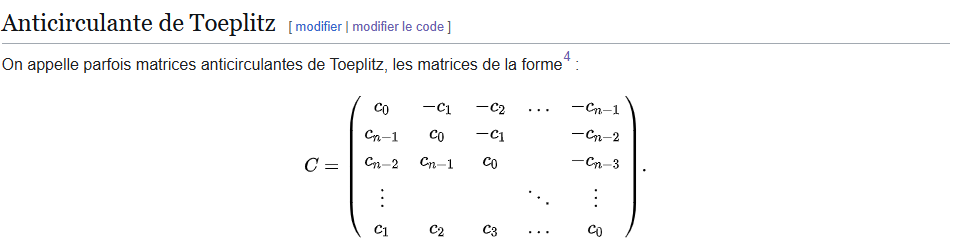
(source : https://fr.wikipedia.org/wiki/Matrices_anticirculantes).

Les matrices anticirculantes sont diagonalisables. 
Si nous posons :
$$ Q = 
\begin{pmatrix}
0 & 0 & 0 & \cdots  & 0 & -1 \\
1 & 0 & 0 & \cdots  & 0 & 0 \\
0 & 1 & 0 & \cdots  & 0 & 0 \\
\vdots & \vdots & \ddots & \vdots  & \vdots & \vdots \\
0 & 0 & 0 & 1  & 0 & 0 \\
0 & 0 & 0 & \cdots  & 1 & 0 \\
\end{pmatrix}
$$
alors nous pouvons écrire $T$ come 
$$ \begin{array}{cc}
T = b_0I + b_1Q + b_2Q^2 + \dots + b_{n-1}Q^{n-1} \\
T = f(Q)
\end{array}
$$
(source : https://arxiv.org/pdf/1908.07154)
Si $Q$ est diagonalisable alors : 
$$
\begin{array}{cc}
Q = MDM^{-1} \\
Q^2 = (MDM^{-1})(MDM^{-1}) = MD^2M^{-1} \\
Q^3 = (MDM^{-1})(MDM^{-1})(MDM^{-1}) = MD^3M^{-1} \\
\dots \\
Q^k = MD^kM^{-1} \\
\end{array}
$$
Nous pouvons en déduire : 
$$
\begin{array}{cc}
T = f(Q)= f(MDM^{-1}) \\
= b_0I + b_1(MDM^{-1}) + b_2(MDM^{-1})^2 + \dots + b_{n-1}(MDM^{-1})^{n-1} \\
= b_0I + b_1(MDM^{-1}) + b_2(MD^2M^{-1}) + \dots + b_{n-1}(MD^{n-1}M^{-1}) \\
= M(b_0I + b_1D + b_2D^2+\dots+b_{n-1}D^{n-1})M^{-1} \\
= Mf(D)M^{-1}
\end{array}
$$
$Q$ est diagonalisable si $det(Q - \lambda I) = 0$. 
On remarque que $Q^N = -I$ donc $Q^N + I = 0$. De cette façon on a $(Q^N + I)v = 0$ pour tout $v$. Donc le polynôme annulateur de $Q$ est $p(X) = X^N +1$. 
Ce polynôme est un polynôme cyclonomique. Sur $\mathbb{C}$ il se factorise en $X^N + 1 = \prod_{k=0}^{N-1}(X - \lambda_k)$ avec $\lambda_k = e^{(2k + 1) \pi i/N}$, les racines toutes distinctes. Comme le polynôme annulateur est scindé et uniquement composé de racines distinctes, alors $Q$ est diagonalisable. 
Nous pouvons maintenant chercher les valeurs propres et vecteurs propres de $Q$. 
$$
\begin{array}{cc}
Qv = \lambda v \\
Q^Nv=  \lambda^Nv \\
\text{Comme } Q^Nv = -v \\
-v = \lambda^N v \\
\lambda^N = -1
\end{array}
$$
Donc les valeurs propres $\lambda_k$ sont exactement les $\lambda_k = e^{(2k + 1) \pi i/N}$. 
On sait que $Qv = \lambda v$ et que $Q$ consiste à cycler vers la gauche les éléments de $v$, i.e : 
$$
Q(v_0, v_1, v_2, \dots, v_{n-1}) = (-v_{n-1}, v_0, v_1, \dots, v_{n-2})
$$
Donc si nous regardons éléments par éléments l'égalité $Qv = \lambda v$ nous avons 
$$ \begin{array}{cc}
-v_{n-1} = \lambda v_0 \\
v_0 = \lambda v_1 \\
v_1 = \lambda v_2 \\
\vdots \\
v_{n-2} = \lambda v_{n-1}
\end{array}
$$
Nous pouvons remonter : 
$$
\begin{array}{cc}
v_{n-2} = \lambda v_{n-1} = \lambda(-(\lambda v_0)) = -\lambda^2v_0 \\
v_{n-3} = \lambda v_{n-2} = \lambda(-\lambda^2v_0) = -\lambda^3v_0 \\
v_{n-4} = \lambda(-\lambda^3v_0) = -\lambda^4v_0 \\ 
\vdots \\
v_0 = - \lambda^{n}v_0
\end{array}
$$
On a donc la relation $v_k = -\lambda^{n-k}v_0$. Comme $v_0 = - \lambda^{n}v_0$ alors $\lambda^n = -1$ donc : 
$$
\begin{array}{cc}
v_k = -\lambda^{n-k}v_0 \\
v_k = -(\lambda^n \cdot \lambda^{-k})v_0 \\
v_k = -(-1 \cdot \lambda^{-k})v_0 \\
v_k = \lambda^{-k}v_0 \\
\text{En posant }\mu = \lambda^{-1} \\
v_k = \mu^kv_0 \\
\text{Comme nous avions }\lambda^n = -1 \\
\mu^n = \lambda^{-n} = -1^{-n} = - 1
\end{array}
$$
Nous avons donc le vecteur propre 
$$
\begin{array}{cc}
v^{<k>} = (v_0, v_1, v_2, \dots, v_{n-1}) \\
= (\mu^{0}v_0, \mu^{1}v_0, \mu^{2}v_0, \dots, \mu^{(n-1)}v_0) \\
= v_0(1, \mu^{1},\mu^{2}, \dots, \mu^{(n-1)}) \\
\end{array}
$$
associé à la valeur  $\mu^{k} = e^{(2k + 1) \pi i/N}$ avec $0 \leq k < N$.
$$
\begin{array}{cc}
Q = MDM^{-1} \\
Q = 
\begin{pmatrix}
v^{<0>} & v^{<1>} & v^{<2>} & \dots & v^{<n-2>} & v^{<n-1>}
\end{pmatrix}
\cdot 
\begin{pmatrix}
\lambda^{<0>} & 0 & 0 & \dots & 0 & 0 \\
0 & \lambda^{<1>} &  0 & \dots & 0 & 0 \\
0 & 0 & \lambda^{<2>} & \dots & 0 & 0 \\
\vdots & \vdots & & \ddots & 0 & 0 \\
0 & 0 & 0 & \dots & \lambda^{<n-2>} & 0 \\
0 & 0 & 0 & \dots & 0 & \lambda^{<n-1>} \\
\end{pmatrix} 
\cdot 
\begin{pmatrix}
v^{<0>} & v^{<1>} & v^{<2>} & \dots & v^{<n-2>} & v^{<n-1>}
\end{pmatrix} ^{-1} \\
= 
\begin{pmatrix}
1 & 1 & 1 & \dots & 1 & 1 \\
\mu^{<0>^{1}} & \mu^{<1>^{1}} & \mu^{<2>^{1}} & \dots & \mu^{<n-2>^{1}}  & \mu^{<n-1>^{1}} \\
\mu^{<0>^{2}} & \mu^{<1>^{2}} & \mu^{<2>^{2}} & \dots & \mu^{<n-2>^{2}}  & \mu^{<n-1>^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
\mu^{<0>^{n-1}} & \mu^{<1>^{n-1}} & \mu^{<2>^{n-1}} & \dots & \mu^{<n-2>^{n-1}}  & \mu^{<n-1>^{n-1}} \\
\end{pmatrix}
\cdot 
\begin{pmatrix}
\lambda^{<0>} & 0 & 0 & \dots & 0 & 0 \\
0 & \lambda^{<1>} &  0 & \dots & 0 & 0 \\
0 & 0 & \lambda^{<2>} & \dots & 0 & 0 \\
\vdots & \vdots & & \ddots & 0 & 0 \\
0 & 0 & 0 & \dots & \lambda^{<n-2>} & 0 \\
0 & 0 & 0 & \dots & 0 & \lambda^{<n-1>} \\
\end{pmatrix} 
\cdot 
\begin{pmatrix}
1 & 1 & 1 & \dots & 1 & 1 \\
\mu^{<0>^{1}} & \mu^{<1>^{1}} & \mu^{<2>^{1}} & \dots & \mu^{<n-2>^{1}}  & \mu^{<n-1>^{1}} \\
\mu^{<0>^{2}} & \mu^{<1>^{2}} & \mu^{<2>^{2}} & \dots & \mu^{<n-2>^{2}}  & \mu^{<n-1>^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
\mu^{<0>^{n-1}} & \mu^{<1>^{n-1}} & \mu^{<2>^{n-1}} & \dots & \mu^{<n-2>^{n-1}}  & \mu^{<n-1>^{n-1}} \\
\end{pmatrix}^{-1} \\
= 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 & 1 \\
\omega^{1} & \omega^{3^{1}} & \omega^{5^{1}} & \cdots & \omega^{(2n-3)^{1}} & \omega^{(2n-1)^{1}} \\
\omega^{2} & \omega^{3^{2}} & \omega^{5^{2}} & \cdots & \omega^{(2n-3)^{2}} & \omega^{(2n-1)^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\omega^{n-1} & \omega^{3^{n-1}} & \omega^{5^{n-1}} & \cdots & \omega^{(2n-3)^{n-1}} & \omega^{(2n-1)^{n-1}} \\
\end{pmatrix}
\cdot 
\begin{pmatrix}
\omega & 0 & 0 & \cdots & 0 & 0 \\
0 & \omega^3 & 0 & \cdots & 0 & 0 \\
0 & 0 & \omega^5 & \cdots & 0 & 0 \\
\vdots & \vdots & & \ddots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & \omega^{2n-3} & 0 \\
0 & 0 & 0 & \cdots & 0 & \omega^{2n-1}
\end{pmatrix}
\cdot 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 & 1 \\
\omega^{1} & \omega^{3^{1}} & \omega^{5^{1}} & \cdots & \omega^{(2n-3)^{1}} & \omega^{(2n-1)^{1}} \\
\omega^{2} & \omega^{3^{2}} & \omega^{5^{2}} & \cdots & \omega^{(2n-3)^{2}} & \omega^{(2n-1)^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\omega^{n-1} & \omega^{3^{n-1}} & \omega^{5^{n-1}} & \cdots & \omega^{(2n-3)^{n-1}} & \omega^{(2n-1)^{n-1}} \\
\end{pmatrix}^{-1}
\end{array}
$$
Comme nous avons les valeurs propres $\lambda^{<k>}$, nous pourrons simplement faire $T = f(Q) = Mf(D)M^{-1}$ en appliquant $f(\cdot)$ au $\lambda^{<k>}$. Ainsi, nous avons : 
$$
\begin{array}{cc}
T = Mf(D)M^{-1} \\ 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 & 1 \\
\omega^{1} & \omega^{3^{1}} & \omega^{5^{1}} & \cdots & \omega^{(2n-3)^{1}} & \omega^{(2n-1)^{1}} \\
\omega^{2} & \omega^{3^{2}} & \omega^{5^{2}} & \cdots & \omega^{(2n-3)^{2}} & \omega^{(2n-1)^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\omega^{n-1} & \omega^{3^{n-1}} & \omega^{5^{n-1}} & \cdots & \omega^{(2n-3)^{n-1}} & \omega^{(2n-1)^{n-1}} \\
\end{pmatrix}
\cdot 
\begin{pmatrix}
f(\omega) & 0 & 0 & \cdots & 0 & 0 \\
0 & f(\omega^3) & 0 & \cdots & 0 & 0 \\
0 & 0 & f(\omega^5) & \cdots & 0 & 0 \\
\vdots & \vdots & & \ddots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & f(\omega^{2n-3}) & 0 \\
0 & 0 & 0 & \cdots & 0 & f(\omega^{2n-1})
\end{pmatrix}
\cdot 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 & 1 \\
\omega^{1} & \omega^{3^{1}} & \omega^{5^{1}} & \cdots & \omega^{(2n-3)^{1}} & \omega^{(2n-1)^{1}} \\
\omega^{2} & \omega^{3^{2}} & \omega^{5^{2}} & \cdots & \omega^{(2n-3)^{2}} & \omega^{(2n-1)^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\omega^{n-1} & \omega^{3^{n-1}} & \omega^{5^{n-1}} & \cdots & \omega^{(2n-3)^{n-1}} & \omega^{(2n-1)^{n-1}} \\
\end{pmatrix}^{-1} \\
\end{array}
$$
et donc la multiplication entre deux polynômes peut être faites de la façon suivante : 
$$
\begin{array}{cc}
A(X) \cdot B(X) = \sum_{i=0}^{n-1} \sum_{j=0}^{n-1} a_i b_j X^{i +j} \\
= Ta =Mf(D)M^{-1}a
\end{array}
$$
L'opération s'effectue toujours en complexité $\mathcal{O}(n^2)$ parce que la transformation $M^{-1}$ et $M$ ont une complexité naïve de $\mathcal{O}(n^2)$ donc on a $\mathcal{O}(n^2) + \mathcal{O}(n) + \mathcal{O}(n^2) = \mathcal{O}(n^2)$. L'opération $M$ est en fait une transformation de Fourrier. Par conséquent, elle peut être transformé en Fast Fourrier Transformation (FFT), qui s'effectue en complexité $\mathcal{O}(n \ log \ n)$. Ainsi, on opère la multiplication polynomiale en $\mathcal{O}(n \ log \ n) + \mathcal{O}(n) + \mathcal{O}(n \ log \ n) = \mathcal{O}(n \ log \ n) < \mathcal{O}(n^2)$.  







# Application 

Voici un exemple jouet d'encodage et de décodage d'un message. 

### Input

Comme vu précédemment, en entrée, nous prenons un vecteur de complexe de taille $N/2$, avec $N$ une puissance de 2. 

In [1]:
import numpy as np 

power_of_two  = 2
n = 2**power_of_two

# y = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y = np.array([1.1 +4.3j, 3.5 - 1.4j])
print(y)

[1.1+4.3j 3.5-1.4j]


### Encodage, 1e étape : Construction de $y'$

Puis nous construisons $y' = (y| \text{ reverse order}(\overline{y}))$. 

In [2]:
y_and_conj = np.concatenate((y, y.conjugate()[::-1]), axis=0)
y_and_conj

array([1.1+4.3j, 3.5-1.4j, 3.5+1.4j, 1.1-4.3j])

### Encodage, 2e étape : Passage en polynôme cyclotomique à coefficient réels

Nous avons défini $V$, l'isomoprhisme d'anneau $\mathbf{R}[X]/X^N +1 \to \hat{\mathbb{C}^N}$ tel que : 
$V\cdot c = y$. Comme nous partons des complexes et nous voulons obtenir les coefficients du polynômes qui sert d'encodage à notre message, nous cherchons 
$$
\begin{array}{cc}
V^{-1}y = c \\ 
\frac{V^T \cdot I^R_N}{N} \cdot y = c
\end{array}
$$

Pour rappel : 
$$
\begin{array}{cc}
\omega = e^{k \pi i/n} \\ \\
V = 
\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix} \\ \\
V^T = 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
\omega & \omega^3 & \omega^5 & \cdots & \omega^{2n-1} \\
(\omega)^2 & (\omega^3)^2 & (\omega^5)^2 & \cdots & (\omega^{2n-1})^2 \\
\vdots & & \ddots & & \vdots \\
(\omega)^{n-1} & (\omega^3)^{n-1} & (\omega^5)^{n-1} & \cdots & (\omega^{2n-1})^{n-1}
\end{pmatrix} \\ \\ 
I^R_N =  
\begin{pmatrix}
0 & \cdots & 0 & 0 & 1 \\
0 & \cdots & 0 & 1 & 0 \\
0 & \cdots & 1 & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
1 & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
\end{array}
$$

In [3]:
V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
w = np.exp(1j * np.pi / n)
for ligne in range(1, n+1, 1):
    for col in range(n): 
        V[ligne-1,col] = (w**(2*ligne -1))**(col)

np.set_printoptions(linewidth=300)
print(V, V.T, sep="\n\n\n")

[[ 1.        +0.j          0.70710678+0.70710678j  0.        +1.j         -0.70710678+0.70710678j]
 [ 1.        +0.j         -0.70710678+0.70710678j  0.        -1.j          0.70710678+0.70710678j]
 [ 1.        +0.j         -0.70710678-0.70710678j  0.        +1.j          0.70710678-0.70710678j]
 [ 1.        +0.j          0.70710678-0.70710678j  0.        -1.j         -0.70710678-0.70710678j]]


[[ 1.        +0.j          1.        +0.j          1.        +0.j          1.        +0.j        ]
 [ 0.70710678+0.70710678j -0.70710678+0.70710678j -0.70710678-0.70710678j  0.70710678-0.70710678j]
 [ 0.        +1.j          0.        -1.j          0.        +1.j          0.        -1.j        ]
 [-0.70710678+0.70710678j  0.70710678+0.70710678j  0.70710678-0.70710678j -0.70710678-0.70710678j]]


In [4]:
reversal_matrix = np.zeros(shape=(n, n))
for i in range(n): 
    reversal_matrix[i,n-1-i] = 1
reversal_matrix

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.]])

In [5]:
# # Exemple de transformation via la reversal matrix 
# exemple_matrix = np.array(([1, 2, 3, 4], [5, 6, 7, 8],  [9, 10, 11, 12], [13, 14, 15, 16]))
# print(
#     exemple_matrix, exemple_matrix @ reversal_matrix, reversal_matrix @ exemple_matrix, sep="\n\n"
# )

In [6]:
v_encoded_as_pol = (V.T @ reversal_matrix)/n @ y_and_conj
v_encoded_as_pol

array([2.3       +0.00000000e+00j, 0.1767767 +2.22044605e-16j, 2.85      +2.22044605e-16j, 1.87383297-2.44249065e-15j])

A cause de la précision de calcul de la machine, la partie imaginaire ne disparaît pas totalement

In [7]:
print(np.max(np.abs(v_encoded_as_pol.imag)))
print(np.mean(np.abs(v_encoded_as_pol.imag)))

2.4424906541753444e-15
7.216449660063518e-16


Je construit une fonction qui pourra être appelé pour vérifier si les parties imaginaire ne sont jamais suffisamment grandes pour être considérées autrement qu'une erreur de précision. 

In [8]:
def check_ckks_imag(v_encoded_as_pol, tol=1e-11):
    imag = np.imag(v_encoded_as_pol)
    real = np.real(v_encoded_as_pol)

    bad = np.where(np.abs(imag) > tol)[0]

    if len(bad) > 0:
        msg = ["Imaginary parts continue to be part of the encoded message"]

        for i in bad:
            msg.append(
                f"Index {i}: {real[i]} + {imag[i]}j (|imag|={abs(imag[i])})"
            )

        raise ValueError("\n".join(msg))

    return real

La tolérance a $1.00000000e-10 \approx 0$. est un choix arbitraire. Tant qu'aucune partie imaginaire n'es tplus grande que ce seuil, nous pouvons décider de ne garder que la partie réel. 

In [9]:
v_encoded_as_pol_appr = check_ckks_imag(v_encoded_as_pol=v_encoded_as_pol)

### Encodage, 3e étape : Passage en polynôme cyclotomique à coefficient entiers

Maintenant, nous allons convertir notre polynôme à coefficient réel en polynôme à coefficient entier en arrondissant les valeurs après les avoir multipliées par le fecteur $\Delta$. Le choix de $\Delta$ doit aussi se faire selon le modulo $t$ choisit.

In [10]:
Delta = 10_000
v__int_encoded_as_pol_appr = np.round(Delta * v_encoded_as_pol_appr, 0)
v__int_encoded_as_pol_appr

array([23000.,  1768., 28500., 18738.])

Comme vous pouvez le voir, plus la valeur de $\Delta$ sera grande, plus la précision gardée lors de l'arrondi sera importante. Il faut garder en tête qu'il quasiment impossible de garder une précision parfaite en utilisant CKKS, car nous avons une approximation lors de l'encodage en polynôme à cause de la précision limitée des machines, une nouvelle approximation au moment de l'arrondi et nous aurons aussi de l'ajout de bruit lors du chiffrement/déchiffrement et des opérations. 

### Décodage : Retour aux vecteurs complexes

Notre message est bien encodé. Nous pouvons travailler dans l'espace sur lequel nous allons chiffrer, faire les opérations et déchiffrer. 
Pour le moment, nous pouvons déjà vérifier que le décodage fonctionne correctement en réalisant l'inverse de l'encodage : 
$$ 
\begin{array}{cc}
Enc(y) = \lfloor \Delta (\frac{V^T \cdot I^R_N}{n} \cdot y') \rceil = \tilde{c} \\ \\
Dec((Enc(y))) = V \cdot \frac{1}{\Delta}\tilde{c}
\end{array}
$$

In [11]:
y_estimated = V @ (1/Delta * v__int_encoded_as_pol_appr)
y_estimated

array([1.10003979+4.29999317j, 3.49996021-1.40000683j, 3.49996021+1.40000683j, 1.10003979-4.29999317j])

Le vecteur obtenu correspond à $V \cdot c = (y | \text{reverse order}(\overline{y}))$. Pour récupérer seulement $y$, il faut prendre uniquement la première moitié du résultat. 

In [12]:
print(y, y_estimated, y_estimated[0:(n//2)], sep="\n")

[1.1+4.3j 3.5-1.4j]
[1.10003979+4.29999317j 3.49996021-1.40000683j 3.49996021+1.40000683j 1.10003979-4.29999317j]
[1.10003979+4.29999317j 3.49996021-1.40000683j]


### Wrapping up 

Maintenant que la démonstration est faite, je vais construire les fonctions qui permettront d'encoder et decoder facilement nos messages. 

In [13]:
def CKKS_Encoding(m, Delta, q=None): 
    n_div_2 = len(m)
    if (n_div_2 & (n_div_2 - 1)) != 0 : 
        n_div_2 = 1 << (n_div_2 - 1).bit_length()
        m = np.concatenate((m, np.zeros(n_div_2 - len(m))), axis=0)
    m_and_conj = np.concatenate((m, m.conjugate()[::-1]), axis=0)
    n = n_div_2*2
    w = np.exp(1j * np.pi / n)
    V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
    for ligne in range(1, n+1, 1):
        for col in range(n): 
            V[ligne-1,col] = (w**(2*ligne -1))**(col)
    reversal_matrix = np.zeros(shape=(n, n))
    for i in range(n): 
        reversal_matrix[i,n-1-i] = 1
    m_encoded_as_pol = (V.T @ reversal_matrix)/n @ m_and_conj
    m_encoded_as_pol_appr = check_ckks_imag(v_encoded_as_pol=m_encoded_as_pol)
    # m_encoded_as_pol_appr = np.real_if_close(m_encoded_as_pol, tol=1_000)
    m_int_encoded_as_pol_appr = np.array(
        [int(round(Delta * x)) for x in m_encoded_as_pol_appr],
        dtype=object
    )
    m_int_encoded_as_pol_appr = np.array([int(x) for x in m_int_encoded_as_pol_appr], dtype=object)
    return m_int_encoded_as_pol_appr

In [14]:
CKKS_Encoding(m=y, Delta=Delta)

array([23000, 1768, 28500, 18738], dtype=object)

In [15]:
def CKKS_decoding(m_encoded, Delta):
    n = len(m_encoded)
    w = np.exp(1j * np.pi / n)
    V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
    for ligne in range(1, n+1, 1):
        for col in range(n): 
            V[ligne-1,col] = (w**(2*ligne -1))**(col)
    y_estimated = V @ (1/Delta * m_encoded)
    return y_estimated[0:(n//2)]

In [16]:
CKKS_decoding(m_encoded=CKKS_Encoding(m=y, Delta=Delta), Delta=Delta)

array([(1.1000397923264287+4.299993165501135j), (3.4999602076735723-1.400006834498866j)], dtype=object)

De cette façon, nous pouvons simplement analyser l'impact sur la précision de la valeur de $\Delta$

In [17]:
Delta_values = [1, 10, 100, 500, 1_000, 10_000, 100_000_000_000_000]

for Delta_value in Delta_values: 
    result = CKKS_decoding(m_encoded=CKKS_Encoding(m=y, Delta=Delta_value), Delta=Delta_value)
    print(y, result , sep="\n")
    erreur = (y - result)
    print(erreur)
    print(f"Erreur de précision pour Delta = {Delta_value} : {erreur}")
    print()

[1.1+4.3j 3.5-1.4j]
[(0.5857864376269046+4.414213562373096j) (3.414213562373096-1.5857864376269053j)]
[(0.5142135623730955-0.11421356237309599j) (0.08578643762690419+0.1857864376269054j)]
Erreur de précision pour Delta = 1 : [(0.5142135623730955-0.11421356237309599j) (0.08578643762690419+0.1857864376269054j)]

[1.1+4.3j 3.5-1.4j]
[(1.0979184719828692+4.384924240491751j) (3.502081528017132-1.4150757595082506j)]
[(0.002081528017130907-0.08492424049175096j) (-0.002081528017131795+0.015075759508250686j)]
Erreur de précision pour Delta = 10 : [(0.002081528017130907-0.08492424049175096j) (-0.002081528017131795+0.015075759508250686j)]

[1.1+4.3j 3.5-1.4j]
[(1.1049895397947347+4.299568901432424j) (3.4950104602052665-1.4004310985675779j)]
[(-0.004989539794734599+0.0004310985675761714j) (0.0049895397947334885+0.00043109856757794773j)]
Erreur de précision pour Delta = 100 : [(-0.004989539794734599+0.0004310985675761714j) (0.0049895397947334885+0.00043109856757794773j)]

[1.1+4.3j 3.5-1.4j]
[(1.09

Plus $\Delta$ est élevé, plus les erreurs se réduisent. Cependant, à cause de la précision des machines, lors les valeurs en entrées sont grandes, peu importe le facteur $\Delta$ choisit, nous ne serons pas capable de retrouver les valeurs de départ après encodage et décodage. 

# Chiffrement homomorphe 


Maintenant que nous pouvons encoder et décoder nos messages, nous allons les chiffrer pour en sécuriser le contenu. Le schéma homomorphe sur lequel repose CKKS est le suivant : 
$$\begin{array}{cc}
Encr(\Delta m_i) = - A_i \times S + \Delta m_i +e_i \\
A_i, S, e_i \in \mathbf{Z}_q[X]/X^N+1 \\
\end{array}
$$
sachant que $A_i$ est public, $S$ est un polynôme à coefficient choisit parmi l'ensemble $\{-1, 0, 1\}$ constituant la clé privée de l'utilisateur et $e_i$ un polynôme à petits coefficients tiré via une gaussienne. La sécurité de ce schéma est basé sur RLWE. Il est facile pour une personne de déchiffrer un message en connaissant $Encr(m_i), A_i, S$ : 
$$
Decr(Encr(\Delta m_i)) = Decr(-A_iS + (\Delta m_i + e_i)) = A_iS - A_iS + (\Delta m_i + e_i) = \Delta m_i + e_i = m_i + \frac{e_i}{\Delta}
$$
Ainsi, le chiffrement puis déchiffrement d'un message encodé renvoi bien le message initial avec un petit bruit en plus. Ce bruit est si petit qu'il est considéré négligeable et donc $m_i + \frac{e_i}{\Delta} \approx m_i$. Ainsi : 
$$
m_i \approx Decr(Encr(\Delta m_i))
$$
C'est donc un schéma de chiffrement approximatif car le résultat après chiffrement et déchiffrement est une approximation du message de départ. L'approximation est considéré si proche du message initial qu'il est utilisable au même titre que le véritable message. Il existe des schémas de chiffrement exact. Nous acceptons la contrainte de l'approximation car elle nous permet d'effectuer efficacement des opérations sur des réels. 

## Chiffrement 

Dans la pratique, le chiffrement d'un message se déroule de la façon suivante : 
$$\begin{array}{cc}
Encr(\Delta m_i) = (A_i,B_i) \\
B_i = -A_iS + \Delta m_i + e_i
\end{array}$$
La paire $(A_i, B_i)$ est l'ensemble du chiffrement qui est envoyé à la partie souhaitant effectuer des opérations sur le message. L'idée est que $A_i$ est indiscernable de $B_i$. Ainsi, une personne qui obtiens ce couple n'est pas capable de reconstruire $m_i$ sans la connaissance de $S$. La partie qui reçoit le message peut ensuite effectuer les opérations directement sur les messages chiffrés. 

In [18]:
def poly_mutl_mod(v1, v2, q, with_modulus=True):
    v1 = np.array(v1, dtype=object)
    v2 = np.array(v2, dtype=object)
    n = len(v1)
    result = [0] * n
    for i in range(n): 
        for j in range(n): 
            coef = (v1[i] * v2[j])
            if (i + j >= n) : 
                result[(i+j) - n] -= coef
            else : 
                result[i+j] += coef

    if with_modulus : 
        for k in range(n) : 
            result[k] = result[k] % q
    
    return np.array(result, dtype=object)

In [19]:
def modulus_centering(x, q):
    return ((x + q//2) % q) - q//2

In [20]:
def mod_for_arb_int(x, q): 
    return np.array([int(v) % q for v in x], dtype=object)

In [21]:
def round_for_arb_int(x): 
    return np.array([int(round(v)) for v in x], dtype=object)

In [22]:
# Création d'un message
y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

# Encodage d'un message
m_i = CKKS_Encoding(m=y_i, Delta=Delta)

B_m = int(np.max(np.abs(m_i)))
B_e = int(np.round(6*(8/np.sqrt(2*np.pi)), 0))    # borne gaussienne grossière

q = int((10*(B_m + B_e))*(Delta**(2)))

In [23]:
# Sampling du masque publique A, un polynôme de degré n-1, modulo Q
rng = np.random.default_rng(12345)  # générateur moderne

In [24]:
# Sampling de la clé privée (évidemment ici la création de la clé n'est pas sécurisé)
S = mod_for_arb_int(np.array(
    [int(x) for x in np.random.randint(-1, 2, size=n)],
    dtype=object
), q)

In [25]:
import random 

A = np.array(
    [random.randrange(0, q) for _ in range(n)],
    dtype=object
)

# Sampling du bruit utilisé pour cacher le message, c'est un petit polynôme de degré n-1
E = np.array(
    [int(x) for x in np.round(rng.normal(loc=0, scale=8/np.sqrt(2*np.pi), size=n))], dtype=object
)

# Construction du chiffrement du message 
B = mod_for_arb_int((poly_mutl_mod(-A, S, q)  + m_i + E), q)

# Construction de la paire (A,B) supposé indiscernable 
Encr_m_i = np.array([A, B])

print("Masque public A", np.polynomial.polynomial.Polynomial((modulus_centering(A, q))), sep="\n")
print()
print("Clé privée S", np.polynomial.polynomial.Polynomial(modulus_centering(S, q)), sep="\n")
print()
print("Bruit pour cacher le message", np.polynomial.polynomial.Polynomial(modulus_centering(E, q)), sep="\n")
print()
print("Paire envoyé au serveur : ", Encr_m_i, sep="\n")
print()
print("Partie A : ", np.polynomial.polynomial.Polynomial(A), sep="\n")
print()
print("Partie B : ", np.polynomial.polynomial.Polynomial(B), sep="\n")

Masque public A
4419766244786 - 5407127471889 x + 2666929308544 x**2 - 1849159168407 x**3

Clé privée S
1 + 1 x - 1 x**2 + 0 x**3

Bruit pour cacher le message
-5 + 4 x - 3 x**2 - 1 x**3

Paire envoyé au serveur : 
[[4419766244786 5822872528111 2666929308544 9380840831593]
 [2294145274668 2836520398445 7159964398128 5005102399184]]

Partie A : 
4419766244786 + 5822872528111 x + 2666929308544 x**2 + 9380840831593 x**3

Partie B : 
2294145274668 + 2836520398445 x + 7159964398128 x**2 + 5005102399184 x**3


## Déchiffrement 

Le déchiffrement du message s'effectue comme suit : 
$$
\begin{array}{cc}
Decr(Encr(\Delta m_i)) = Decr(A_i, B_i) \\
= Decr(A_i, -A_iS + (\Delta m_i + e_i)) \\ 
= A_iS - A_iS + (\Delta m_i + e_i) = \Delta m_i + e_i = m_i + \frac{e_i}{\Delta}
\end{array}
$$

In [26]:
Decr_m_i = round_for_arb_int((mod_for_arb_int((B + poly_mutl_mod(A, S, q)), q)) * Delta) // Delta
print(Decr_m_i, (m_i) % q, sep="\n")

[11229999996405 2935 11229999989997 11210]
[11229999996410 2931 11229999990000 11211]


Nous pouvons comparer la différence de valeur entre le message avant chiffrement et après pour faire apparaître le bruit qui lui est ajouté. 

In [27]:
import matplotlib.pyplot as plt 

def Show_encryption_impact(m, m_encr_decr, q, in_percent=False):

    m_c = modulus_centering(m, q)
    m_dec_c = modulus_centering(m_encr_decr, q)

    impact = np.abs(m_c - m_dec_c)

    if in_percent:
        impact = impact * 100 / (np.abs(m_c) + 1e-6)

    max_noise = np.max(impact)
    print("max noise:", max_noise)

    plt.figure(figsize=(8,5))
    bins = np.linspace(0, max_noise, 10)

    plt.hist(impact, bins=bins)

    plt.xlabel("Erreur (centrée modulo q)")
    plt.ylabel("Fréquence")
    plt.title("Histogramme du bruit")
    plt.grid(True, alpha=0.3)
    plt.show()

max noise: 5


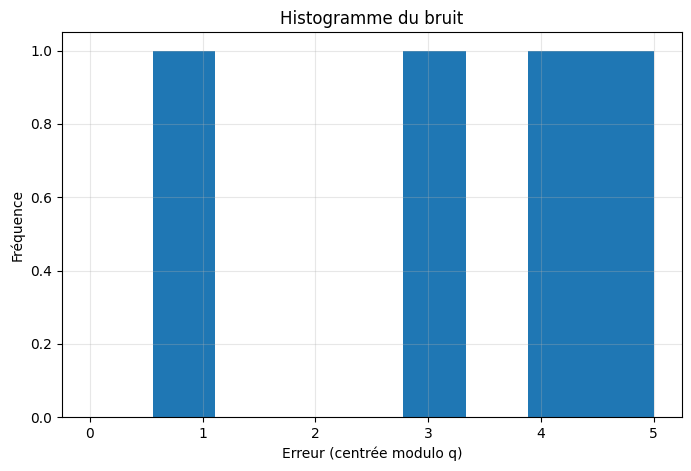

In [28]:
Show_encryption_impact(m=m_i % q, m_encr_decr=Decr_m_i, q=q)

Nous retrouvons bien le bruit gaussien centré en $0$. Nous pouvons wrap-up les opérations dans des fonctions pour plus de lisibilité. 

In [29]:
def CKKS_Encryption(m_encoded, q, S): 
    n = len(m_encoded)
    # rng = np.random.default_rng()  # générateur moderne
    A = np.array(
    [random.randrange(0, q) for _ in range(n)],
    dtype=object
    )
    E = np.array(
    [int(x) for x in np.round(rng.normal(loc=0, scale=8/np.sqrt(2*np.pi), size=n))], dtype=object
    )
    # E = np.zeros(n, dtype=object)
    B = mod_for_arb_int((poly_mutl_mod(-A, S, q)  + m_encoded + E), q)
    Encr_m = np.array([A, B])
    return Encr_m

In [30]:
def CKKS_Decryption(Encr_m, S, Delta, q): 
    A = Encr_m[0]
    B = Encr_m[1]
    Decr_m = round_for_arb_int((mod_for_arb_int((B + poly_mutl_mod(A, S, q)), q)) * Delta) // Delta
    return Decr_m

In [31]:
# Création de deux messages
y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y_j = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

# Encodage de deux messages
m_i = CKKS_Encoding(m=y_i, Delta=Delta)
m_j = CKKS_Encoding(m=y_j, Delta=Delta)

# Chiffrement des deux messages 
Encr_m_i = CKKS_Encryption(m_encoded=m_i, q=q, S=S)
Encr_m_j = CKKS_Encryption(m_encoded=m_j, q=q, S=S)

[10403 11229999994184 9999 5819]
[10405 11229999994181 10000 5819]
max noise: 3


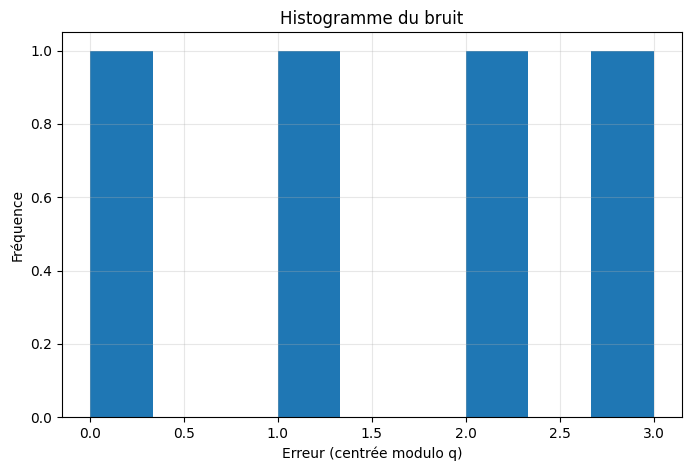

In [32]:
m_encr_decr = CKKS_Decryption(
    CKKS_Encryption(
        m_encoded=m_i, q = q, S=S
        ), S=S, Delta=Delta, q=q
    )

print(m_encr_decr, (m_i) % q, sep="\n")

Show_encryption_impact(m=m_i, m_encr_decr=m_encr_decr, q=q)

Le but de CKKS est de chiffrer un message, puis d'effecteur un certain nombre d'opérations avec ce message chiffré puis de déchiffrer le résultat. En théorie, il n'y a pas plusieurs fois le chiffrement et le déchiffrement d'un même message, donc le bruit ne va pas s'accumuler par ce biais là. Nous pouvons considérer que chiffrer et déchiffrer sera toujours safe de ce point de vue là, c'est à dire que nous aurons toujours un approximation assez fidèle du message original. 

## Addition de messages chiffrés 


L'addition de deux messages chiffrés est définie en additionnant chaque partie du couple chiffré : 
$$
\begin{array}{cc}
Encr(\Delta m_i) + Encr(\Delta m_j) = (A_i, B_i) + (A_j, B_j) \\
= (A_i + A_j, B_i + B_j) \\
= (A_i + A_j, (-A_iS + \Delta m_i + e_i) + (-A_jS + \Delta m_j + e_j)) \\
= (A_i + A_j, -S(A_i + A_j) + \Delta m_i + \Delta m_j + e_i + e_j) \\ 
\text{En possant} A_i + A_j = A_k, B_i + B_j = B_k \\
= (A_k, B_k)
\end{array}
$$

D'abord nous allons créer, encoder et chiffrer deux messages, à l'aide de notre clé privé et de bruit. 

In [33]:
# Création de deux messages
y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y_j = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

# Encodage de deux messages
m_i = CKKS_Encoding(m=y_i, Delta=Delta)
m_j = CKKS_Encoding(m=y_j, Delta=Delta)

# Chiffrement des deux messages 
Encr_m_i = CKKS_Encryption(m_encoded=m_i, q=q, S=S)
Encr_m_j = CKKS_Encryption(m_encoded=m_j, q=q, S=S)

Puis, nous additionons les messages chiffrés entre eux. 

In [34]:
Encr_m_i_add_m_j = np.array(
    [
    mod_for_arb_int(Encr_m_i[0] + Encr_m_j[0], q), 
    mod_for_arb_int(Encr_m_i[1] + Encr_m_j[1], q)
    ], dtype=object
)

Puis nous pouvons déchiffrer le message : 
$$
\begin{array}{cc}
Decr((A_k, B_k))
= B_k + S(A_i + A_j) \\
=(-S(A_i + A_j) + S(A_i + A_j) + \Delta m_i + \Delta m_j + e_i + e_j) \\
= \Delta m_i + \Delta m_j + e_i + e_j \\ 
= m_i + m_j + \frac{e_1 + e_2}{\Delta} \approx m_i + m_j
\end{array}
$$
Si nous comparons avec l'addition faites avant le chiffrement : 
$$
\begin{array}{cc}
Decr(Encr(\Delta m_i + \Delta m_j)) = Decr(A, -AS + (\Delta m_i + \Delta mj_j + e)) \\
= AS - AS + (\Delta m_i + \Delta mj_j + e) \\
= (\Delta m_i + \Delta mj_j + e) \approx m_i + m_j + \frac{e}{\Delta}
\end{array}
$$
Comme $m_i + m_j + \frac{e_1 + e_2}{\Delta} \approx (\Delta m_i + \Delta mj_j + m_i + m_j + \frac{e}{\Delta})$ alors nous avons bien $Decr(Encr(\Delta m_i) + Encr(\Delta m_j) \approx Decr(Encr(\Delta m_i + \Delta m_j))$.


In [35]:
result_addition = CKKS_Decryption(
    Encr_m=Encr_m_i_add_m_j, S=S, Delta=Delta, q=q
    )

print((result_addition), ((m_i+m_j)), sep="\n")

[11229999986674 11229999986405 20005 11229999971162]
[-13333 -13590 20000 -28837]


max noise: 7


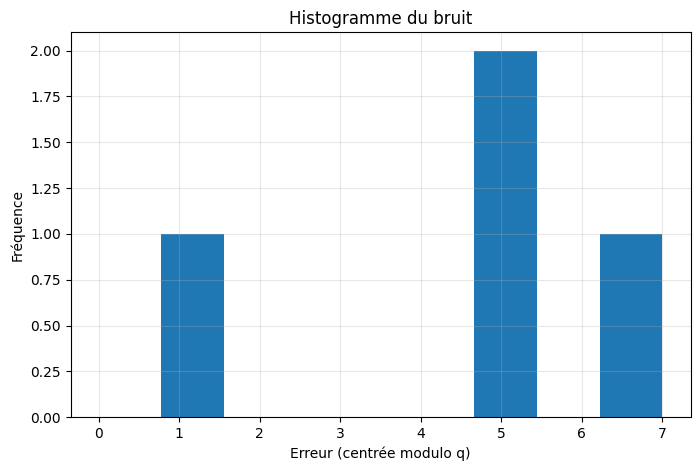

In [36]:
Show_encryption_impact(m=(m_i+m_j)% q, m_encr_decr=result_addition, q=q)

Le bruit ajouté lors d'une addition de deux messages chiffrés est $\frac{e_i + e_j}{\Delta}$. Comme les $e$ sont très petits, ce bruit est négligeable. 

L'addition entre un message chiffré et un message non chiffré est possible, et s'effectue de façon similaire : 
$$
\begin{array}{cc}
Encr(\Delta m_i) + \Delta m_j = (A_i, B_i) + \Delta m_j \\
= (A_i, -A_iS + \Delta m_i + e_i + \Delta m_j ) \\
= Encr(\Delta(m_i + m_j))
\end{array}
$$


In [37]:
# Création de deux messages
y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y_j = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

# Encodage de deux messages
m_i = CKKS_Encoding(m=y_i, Delta=Delta)
m_j = CKKS_Encoding(m=y_j, Delta=Delta)

In [38]:
# Chiffrement des deux messages 
Encr_m_i = CKKS_Encryption(m_encoded=m_i, q=q, S=S)

In [39]:
Encr_m_i_add_m_j_plt = np.array(
    (
    Encr_m_i[0], 
    mod_for_arb_int(Encr_m_i[1] + m_j, q)
    )
)

Puis 
$$
\begin{array}{cc}
Decr((A_i, -A_iS + \Delta m_i + e_i + \Delta m_j)) \\
= A_iS - A_iS + \Delta m_i + \Delta m_j + e_i \\ 
= m_i + m_j + \frac{e_i}{\Delta} \approx m_i + m_j
\end{array}
$$
A nouveau $Decr(Encr(\Delta m_i)) + \Delta m_j) =\Delta m_i + e_i + \Delta m_j = m_i + m_j + \frac{e_i}{\Delta} = Decr(Encr(\Delta m_i) + \Delta m_j)$.

[11229999986160 11229999971056 11229999979996 11229999986519]
[11229999986161 11229999971055 11229999980000 11229999986519]
max noise: 4


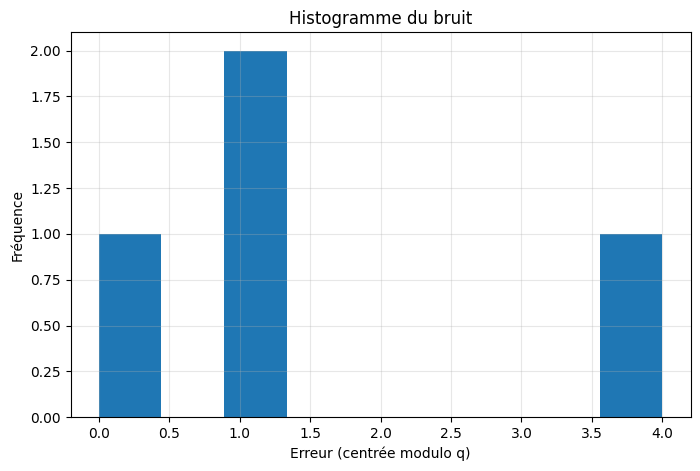

In [40]:
result_addition_plt = CKKS_Decryption(
    Encr_m=Encr_m_i_add_m_j_plt, S=S, Delta=Delta, q=q
    )

print(result_addition_plt, ((m_i+m_j) % q), sep="\n")

Show_encryption_impact(m=(m_i+m_j) % q, m_encr_decr=result_addition_plt, q=q)

Le bruit ajouté lors d'une addition d'un message chiffé avec un message non chiffré est $\frac{e_i}{\Delta}$. Il semble donc que l'addition d'un chiffré et d'un non chiffré soit moins approximative que dans le cas de l'addition de deux chiffrés mais il faut garder en tête que les $e$ sont très petits donc dans les deux cas le bruit ajouté est négligeable.

A la différence du chiffrement, il est possible que de nombreuses additions se suivent lors du traitement des messages. Par conséquent, le bruit va augmenter de $\frac{e_i + e_j}{\Delta} \times \text{|addition|}$. Le bruit étant très petit et le $\Delta$ choisit pouvant être très grand, il est possible de faire un grand nombre d'addition avant que le bruit ajouté soit trop important. Une façon de définir un budget d'opérations peut être de travailler modulo $q$. Ainsi, lorsque l'opération suivante entraînerait le dépassement du modulo, alors le résultat n'aura plus de lien avec le résultat souhaité, donc le budget d'opérations aurait été dépassé. Il convient donc de choisir le modulo en accord avec le nombre d'opérations que nous souhaitons faire mais aussi avec l'erreur de précision maximum que nous pouvons tolérer sur le résultat final. 

## Multiplication 

La multiplication de deux nombres chiffrés puis déchiffrés nous donne : 
$$
\begin{array}{cc}
Decr(Encr(\Delta m_i)) \cdot Decr(Encr(\Delta m_j)) \\ 
(\Delta m_i + e_i)(\Delta m_j + e_j) \\
= \Delta^2 m_i m_j + \Delta(m_ie_j + m_je_i) + e_ie_j \\
\approx \Delta^2 m_i m_j
\end{array}
$$
SI nous nous concentrons sur les opérations de ciphertext nous avons : 
$$
\begin{array}{cc}
Decr(Encr(\Delta m_i)) \cdot Decr(Encr(\Delta m_j)) \\ 
= (B_i + A_iS)(B_j + A_jS) \\
= B_iB_j + B_iA_jS + B_jA_iS + S^2A_iA_j \\
=\underbrace{B_iB_j}_{D_0} + S\underbrace{(A_iB_j + A_jB_i)}_{D_1} + S^2\underbrace{(A_iA_j)}_{D_2}
\end{array}
$$

Pour avoir un résultat tel que $Decr(Encr(\Delta m_i)) \cdot Decr(Encr(\Delta m_j)) \approx Decr(Encr(\Delta m_i) ?Encr(\Delta m_j))$, nous avons besoin de produire à partir de $Encr(\Delta m_i)?Encr(\Delta m_j)$ les trois parties $D_0, D_1, D_2$, que nous viendront ensuite évalue en $S$ au moment du déchiffrement. Donc nous avons la multiplication de chiffrés suivante : 

$$\begin{array}{cc}
Encr(\Delta m_i)?Encr(\Delta m_j) \\
= (A_i, B_i)\otimes(A_j, B_j) \\
= (B_iB_j, A_iB_j + A_jB_i, A_iA_j) \\ 
= (D_0, D_1, D_2)
\end{array}
$$

Puis pour déchiffrer, nous pouvons simplement faire : 
$$
\begin{array}{cc}
Decr(D_0, D_1, D_2)= D_0 + D_1S + D_2S^2 \\ 
= \Delta ^2 m_i m_j + \Delta(m_ie_j + m_je_i + e_ie_j) \\
\approx \Delta^2m_im_j
\end{array}
$$ 

Nous avons donc un schéma capable d'évaluer de façon homomorphe la multiplication. Pour se faire, nous avons besoin d'évaluer notre résultat chiffrer en $S$ et en $S^2$. Cependant, nous sortons du problème standard $RLWE$ où nous avons $(A, B)$ supposé indiscernable et où nous déchiffrons en $B + AS$. Donc nous allons avoir besoin de passer d'une évaluation en $S^2$ à une évaluation en $S$. C'est la "relinéarisation". 

### Relinéarisation


L'idée est que nous aimerions passer de $D_0 + D_1S + D_2S^2$ à $F_0 + F_1S$. Nous pouvons déjà remarquer de $D_O + D_1S = Decr(D_0, D_1)$.  
Ensuite, nous devons factoriser $D_2S^2$ mais sans utiliser directement $S$ car nous somme dans l'espace des chiffrés, donc $S$ nous est inconnu. En théorie, nous pourrions simplement envoyer $S^2$ chiffré pour que l'évaluateur puisse l'utiliser dans ses calculs :  
$$
\begin{array}{cc}
D_2 \otimes Encr(S^2) \\
= D_2 \otimes (S^2 + e)  \\
D_2S^2 + D_2e \\
D_2S^2 + A_iA_je
\end{array}
$$
Le problème est que l'erreur $A_iA_je$ est trop importante pour que le résultat déchiffre correctement. Nous pouvons noter que lors de la multiplication d'un plaintext avec un ciphertext, le bruit qui en résultat est $\text{plaintext} \cdot e$. Ainsi, le bruit dépend ne dépend que de la taille du plaintext. Une idée serait donc de transformer $D_2 S^2$ de façon à réduire $D_2$ et à augmenter $S^2$ pour contrebalancer. Par exemple, nous pourrions faire : 
$$
\begin{array}{cc}
\frac{D_2}{2} \otimes Encr(2S^2) \\
= D_2S^2 + \frac{D_2}{2}e
\end{array}
$$
De cette façon, nous avons réussi à réduire le bruit par deux. Cependant, l'évaluateur ne connait pas $S_2$, il ne connait que $Encr(S^2)$ et l'envoyeur ne connait pas $D_2$ avant de devoir envoyer $Encr(S_2)$. Par conséquent, nous ne pouvons pas calculer à l'avancer le $PGCD(D_2, S^2) = d$ puis envoyer $Encr(lS^2)$ puis que l'évaluateur fasse $\frac{D_2}{d} \otimes Encr(dS^2)$. Nous pourrions imaginer que l'utilisateur envoie à l'avance tout les multiples possibles de $S$ mais cela en représenterait naïvement $q$, avec $q$ un nombre très grand. Cela n'est pas réaliste. Donc nous avons besoin d'une décomposition qui soit assez générale pour fonctionner dans tout les cas de figures et si possible qui ne demande pas à l'envoyeur de transmettre trop de multiples de $S_2$. 

Une façon de faire est d'utiliser la "gagdet decomposition". 

#### Gadget decomposition

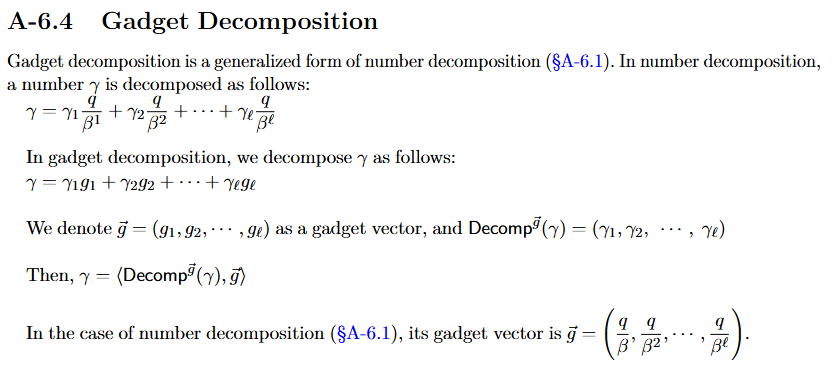

(source : https://arxiv.org/pdf/2503.05136)

Ainsi, nous décomposons $D_2$ en base $\beta$ et de niveau $\ell$ comme suit ($q$ est le plus grand numérateur possible comme nous travaillons en modulo $q$, donc le dernier facteur de décomposition sera forcément $\frac{q}{q} = \frac{q}{\beta^\ell}$, donc $\beta = q^{1/ \ell}$ ) : 
$$
\begin{array}{cc}
D_2 = \langle Decomp^g(D_2), g \rangle \\
g = (\frac{q}{\beta}, \frac{q}{\beta^2}, \dots, \frac{q}{\beta^\ell})  \\
Decomp^g(D_2) = (D_{2,1}, D_{2,2}, \dots, D_{2,\ell}) \\
\end{array}
$$
Nous avons la relation 
$$
\begin{array}{cc}
 \langle Decomp^g(D_2), g> \otimes Encr(S^2) \rangle \\
= D_2 \otimes Encr(S^2) \\
= D_2S^2 + A_iA_je
\end{array}
$$
Nous souhaitons augmenter le chiffré pour diminuer le plaintext car le bruit dépend du plaintext : 
$$
\begin{array}{cc}
\langle Decomp^g(D_2), (Encr(\frac{q}{\beta}S^2), Encr(\frac{q}{\beta^2}S^2), \dots, Encr(\frac{q}{\beta^\ell})) \rangle \\
= \langle Decomp^g(D_2), RLeV^{\beta, \ell} \rangle \\
= D_{2,1} Encr(\frac{q}{\beta}S^2) + D_{2,2} Encr(\frac{q}{\beta^2}S^2) + \dots + D_{2,\ell} Encr(\frac{q}{\beta^\ell}S^2) \\
= D_{2,1}(\frac{q}{\beta}S^2 + e_1) + D_{2,2}(\frac{q}{\beta^2}S^2 + e_2) + \dots + D_{2,\ell}(\frac{q}{\beta^\ell}S^2 + e_\ell) \\
= \frac{q}{\beta}D_{2,1} S^2 + D_{2,1}e_1 + \frac{q}{\beta^2}D_{2,2} S^2 + D_{2,2}e_2 + \dots + \frac{q}{\beta^\ell}D_{2,_\ell} S^2 + D_{2,\ell}e_\ell \\
= S^2(\frac{q}{\beta}D_{2,1} + \frac{q}{\beta^2}D_{2,2} + \dots + \frac{q}{\beta^\ell}D_{2,\ell}) + \sum_{i = 1}^\ell (D_{2,i} e_i) \\
= D_2S^2 + \sum_{i = 1}^\ell (D_{2,i} e_i)
\end{array}
$$
Pour savoir si $\sum_{i = 1}^\ell (D_{2,i} e_i)$ est négligeable ou non, nous devons connaitre $|D_{2,i}|$ :  
$$
\begin{array}{cc}
\langle Decomp^g(D_2), g \rangle = D_{2,1}\frac{q}{\beta} + D_{2,2}\frac{q}{\beta^2} + \dots + D_{2,\ell}\frac{q}{\beta^\ell} \\
\text{Comme q = } \beta^\ell \\
= D_{2,1}\frac{\beta^\ell}{\beta} +  D_{2,2}\frac{\beta^\ell}{\beta^2} + \dots + D_{2,\ell}\frac{\beta^\ell}{\beta^\ell} \\
= D_{2,1}\beta^{\ell - 1} + D_{2,2}\beta^{\beta^{\ell - 2}} + \dots + D_{2,\ell}\beta^0
\end{array}
$$
Ainsi, $0 \leq |D_{2,i}| \leq \beta$, et $\beta = q^{1/\ell}$. Donc plus le niveau de décomposition $\ell$ est grand, plus $|D_{2,i}|$ sera petit. Nous souhaitons connaître $e_{relin} = |\sum_{i = 1}^\ell (D_{2,i} e_i)|$. Nous savons que $|D_{2,i}| \leq \beta$ et $|e_i| \leq \sigma$ donc $|e_{relin}| = \ell\beta\sigma = \ell q^{1/\ell}\sigma$.
Nous cherchons 
$$
\begin{array}{cc}
\underset{\ell}{\operatorname{arg \min}}\ f(\ell) = \ell q^{1/\ell}\sigma \\
q^{1/\ell} = e^{ln(q)/\ell} \\
f(\ell) = \ell e^{ln(q)/\ell}\sigma \\
f'(\ell) = e^{ln(q)/\ell} + \ell(\frac{d(e^{ln(q)/\ell})}{d\ell}) \\
\frac{d(e^{ln(q)/\ell})}{d\ell} = \frac{d(ln(q)/\ell)}{dl} e^{ln(q)/\ell} \\
= - \frac{ln(q)}{\ell^2} e^{ln(q)/\ell} \\
f'(\ell) = e^{ln(q)/\ell} - \ell \frac{ln(q)}{\ell^2} e^{ln(q)/\ell} \\
= q^{1/\ell} - \frac{ln(q)}{\ell} q^{1/\ell} \\
= q^{1/\ell} (1 - \frac{ln(q)}{\ell}) \\
q^{1/\ell} (1 - \frac{ln(q)}{\ell}) = 0 \\
 (1 - \frac{ln(q)}{\ell}) = 0 \\
 1 = \frac{ln(q)}{\ell} \\
 \ell = ln(q)
\end{array}
$$
Ainsi, on minimise le bruit lorsque $\ell = ln(q)$, soit $ln(q)q^{1/ln(q)}\sigma = ln(q) {e^{ln(q)}}^{1/ln(q)} \sigma = ln(q) e \sigma$. En pratique, on choisit plutôt $\ell < ln(q)$ pour limiter le nombre de clé privée chiffrée à envoyer à l'évaluateur, donc on s'expose à un bruit plus important, mais qui n'empêche de déchiffrer sur un résultat qui reste correct. Au final, nous réalisons la multiplication de chiffré comme suit : 
$$
\begin{array}{cc}
Encr(\Delta m_i) \otimes Encr(\Delta m_j) = (A_i, B_i)\otimes (A_j, B_j) \\
= (D_1, D_0) + \langle Decomp^g(D_2), RLev^{\beta, \ell} (S^2) \rangle \\
=  (A_iB_j + A_jB_i, B_iB_j) + \langle Decomp^g(A_iA_j), RLev^{\beta, \ell} (S^2) \rangle \\
\end{array}
$$

Puis, nous déchiffrons  :
$$
\begin{array}{cc}
Decr \big( (D_1, D_0) + \langle Decomp^g(D_2), RLev^{\beta, \ell} (S^2) \rangle \big) \\
\approx Decr(D_1, D_0) + Decr(\langle Decomp^g(D_2), RLev^{\beta, \ell} (S^2) \rangle) \\
\approx D_0 + D_1S + D_2S^2 \\
\approx \Delta^2 m_i m_j
\end{array}
$$

La multiplication fonctionne mais nous aimerions un résultat $\Delta m_i m_j$ et non $\Delta^2 m_i m_j$ pour avoir $Decr(Encr(\Delta m_i) \otimes Encr(\Delta m_j)) \approx Decr(Encr(\Delta(m_i m_j))$. 
C'est l'étape du "rescaling". 
Nous ne pouvons pas directement diviser par $\Delta$ dans l'espace des chiffrés car nous travaillons modulo $q$, donc l'inverse d'un élément n'existe pas toujours et même s'il existe, la division n'est pas définie de manière unique. Une façon de divisier par $\Delta$ est d'utiliser le "modulo rescaling". 


### Rescaling

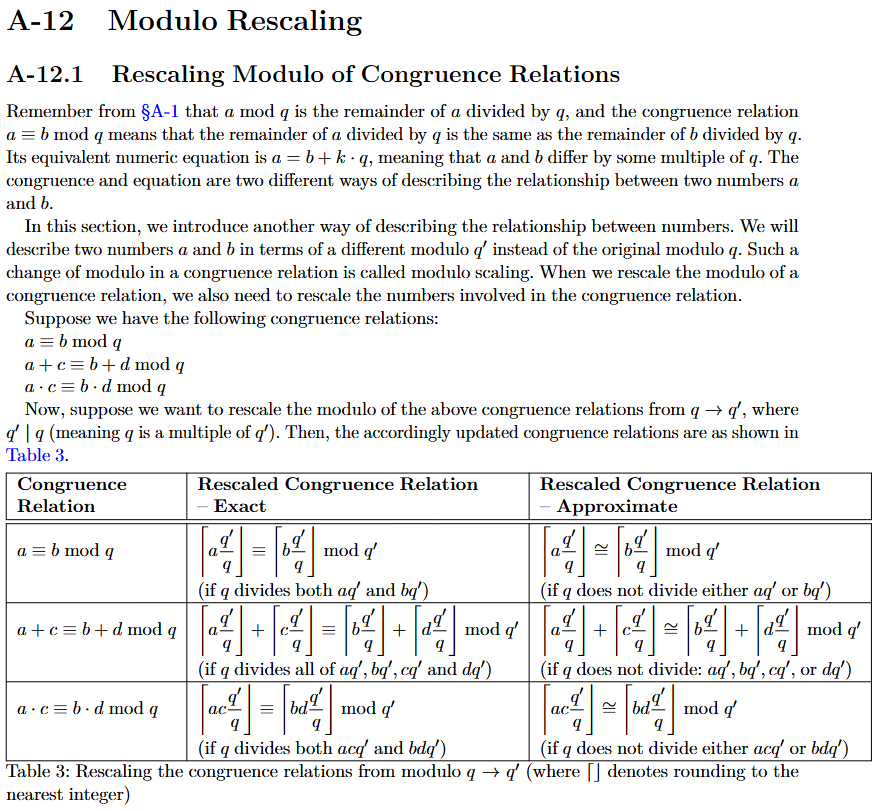

(source : https://arxiv.org/pdf/2503.05136)

En reprenant, si j'ai $a \equiv b \text{ mod } q$, $q' |q$ et $q = pq'$ alors 
$$
\begin{array}{cc}
a \equiv b \text{ mod } q \\
a = b + k \times q \\
a = b + k \times pq' \\
a \frac{q'}{q} = b\frac{q'}{q} + k \times pq'\frac{q'}{q} \\
a \frac{q'}{q} = b\frac{q'}{q} + k \times q' \\
a \frac{q'}{q} = b\frac{q'}{q} \text{ mod } q'
\end{array}
$$
$a \frac{q'}{q}$ et $b\frac{q'}{q}$ ne sont pas forcément des entiers. Comme nous travaillons dans les entiers, nous avons besoin d'arrondir pour être sûr de rester dans le bon espace : 
$$
\begin{array}{cc}
a \frac{q'}{q} = b\frac{q'}{q} \text{ mod } q' \\
\lceil a \frac{q'}{q} \rfloor \approx \lceil b\frac{q'}{q} \rfloor \text{ mod } q'
\end{array}
$$

Grâce à ce modulo rescaling, j'arrive au final à multiplier par $\frac{q'}{q}$ ce qui revient à diviser par $\frac{q}{q'} = \frac{pq'}{q'} = p$. Donc en choisissant $p = \Delta$, je peux diviser mon ciphertext par $\Delta$. J'ai donc $q = \Delta q'$. Et si je veux pouvoir rescale plusieurs fois, car je souhaite faire plusieurs multiplications avant de déchiffrer, je dois avoir : 
$$
\begin{array}{cc}
q = \Delta q' \\
q' = \Delta q'' \\
\vdots \\
q_0 = \Delta q_1
\end{array}
$$
Au final $q = \Delta^o q_0$ avec $o$ le nombre de multiplications que je souhaite effectuer dans l'espace des chiffrés. Cela implique que $q$ est un multiple de $q'$ et donc n'est pas premier. Il faut aussi que $q_0$ soit suffisamment grand pour qu'une fois arriver à $mod \ q_0$, il y ai encore suffisamment d'espace pour contenir le résultat qui va être déchiffré, soit au minimum $q_0 > \Delta m_{i + j} + e$. Comme $q_0$ doit être suffisamment grand alors $q = \Delta^o q_0$, explose rapidement et nous serons limiter qu'à un faible nombre de multiplication avant de devoir déchiffrer car ne ne pourrons plus diviser par $\Delta$. Une solution à cela est de passer par Residue Number System. Pour rappel : 

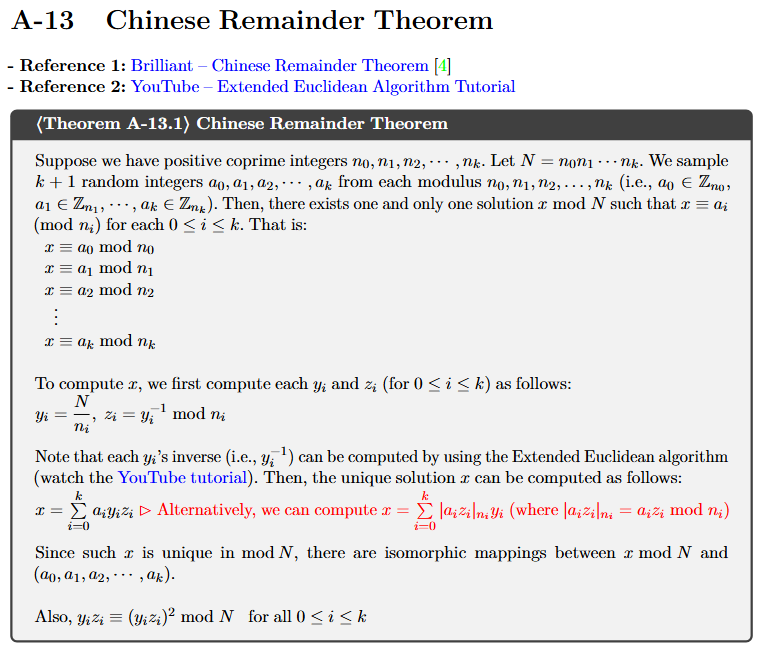

(source : https://arxiv.org/pdf/2503.05136)

ce qui nous permet de représenter cette valeur comme $\Delta^2 m_i m_j \text{ mod }q \rightarrow (a_0, a_1, \dots, a_k)$. Cette représentation permet de réduire la taille de chaque nombre manipuler et de paralléliser les calculs. Nous ne pouvons donc plus construire $q = q_0 \Delta^o$ car les $\Delta$ ne seront pas copremiers entre eux. Pour qu'ils puissent être copremiers entre eux, nous devons relaxer l'égalité en $n_i \approx \Delta$ tout en gardant $n_0 = q_0$. Pour garder le POC simple, je vais utiliser le système $q = \Delta^o q_0$. 

### Calcul du modulo 

Comme la multiplication de deux chiffrés entraînent une augmentation importante du bruit, qui ne sera réduit qu'après rescaling, il faut s'assurer que notre espace de chiffré puisse acceuillir $|(\Delta m_i + e_i) \times \Delta m_j + e_j)| = |\Delta ^2 m_i m_j + \Delta(m_i e_j + m_j e_i) + e_i e_j|$. 

In [41]:
maximum = 0 

#Méthode sampling pour avoir une idée de la taille maximum de multiplication de message 
for i in range(100_000):
    y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
    y_j = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

    # Encodage de deux messages
    m_i = CKKS_Encoding(m=y_i, Delta=Delta)
    m_j = CKKS_Encoding(m=y_j, Delta=Delta)

    # print(m_i, m_j, (poly_mutl_mod(m_i, m_j, q=q, with_modulus=False), q), sep="\n")
    for value in poly_mutl_mod(m_i, m_j, q=q, with_modulus=False): 
        if np.abs(value) > maximum : 
            maximum = int(np.abs(value))
            print(maximum)

175225385
268282675
340029868
364996114
397046062
632299635
835295537
849671190
900169303
948059636
954429220
955926019
1030444535
1116628953


In [42]:
#Détermine la précision après la virgule 
Delta = (10_000_000)
#Taille maximale d'un input encodé
max_size_m = maximum*2 
# max_size_m = 2**60 
#Taille de l'input encodé avec du bruit 
max_size_m_delta_noised = max_size_m * Delta + 2*13
#Taille induite par la multiplication 
max_size_q = max_size_m_delta_noised**2
#Taille induite par le nombre de multiplication 
max_size_q_max_op = max_size_q*(Delta**500)

In [43]:
q = max_size_q_max_op

S = mod_for_arb_int(np.array(
    [int(x) for x in np.random.randint(-1, 2, size=n)],
    dtype=object
), q)

### Création des entrées 

In [44]:
# # Création de deux messages
y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y_j = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

# Encodage de deux messages
m_i = CKKS_Encoding(m=y_i, Delta=Delta)
m_j = CKKS_Encoding(m=y_j, Delta=Delta)

# Chiffrement des deux messages 
Encr_m_i = CKKS_Encryption(m_encoded=m_i, q=q, S=S)
Encr_m_j = CKKS_Encryption(m_encoded=m_j, q=q, S=S)

### Premier ciphetext : $(D_1, D_0)$

In [45]:
# Premier ciphertext 
A_i, B_i = Encr_m_i[0], Encr_m_i[1]
A_j, B_j = Encr_m_j[0], Encr_m_j[1]
D_0 = (poly_mutl_mod(B_i, B_j, q))
D_1 = mod_for_arb_int((poly_mutl_mod(A_i, B_j, q) + poly_mutl_mod(A_j, B_i, q)), q)

first_ciph = np.array((D_1, D_0))

### Deuxième ciphertext : $\langle Decomp^g(D_2), RLev^{\beta, \ell} (S^2) \rangle $

Pour rappel : 
$$
\begin{array}{cc}
\langle Decomp^g(D_2), (Encr(\frac{q}{\beta}S^2), Encr(\frac{q}{\beta^2}S^2), \dots, Encr(\frac{q}{\beta^\ell})) \rangle \\
= \langle Decomp^g(D_2), RLeV^{\beta, \ell} \rangle \\
= D_{2,1} Encr(\frac{q}{\beta}S^2) + D_{2,2} Encr(\frac{q}{\beta^2}S^2) + \dots + D_{2,\ell} Encr(\frac{q}{\beta^\ell}S^2) \\
= D_{2,1}(\frac{q}{\beta}S^2 + e_1) + D_{2,2}(\frac{q}{\beta^2}S^2 + e_2) + \dots + D_{2,\ell}(\frac{q}{\beta^\ell}S^2 + e_\ell) \\
= \frac{q}{\beta}D_{2,1} S^2 + D_{2,1}e_1 + \frac{q}{\beta^2}D_{2,2} S^2 + D_{2,2}e_2 + \dots + \frac{q}{\beta^\ell}D_{2,_\ell} S^2 + D_{2,\ell}e_\ell \\
= S^2(\frac{q}{\beta}D_{2,1} + \frac{q}{\beta^2}D_{2,2} + \dots + \frac{q}{\beta^\ell}D_{2,\ell}) + \sum_{i = 1}^\ell (D_{2,i} e_i) \\
= D_2S^2 + \sum_{i = 1}^\ell (D_{2,i} e_i)
\end{array}
$$

Donc nous avons besoin de définir un niveau de décomposition $\ell$ et un facteur $\beta$, puis de calculer à la fois les $\frac{q}{\beta^i} = \beta^{\ell - i}$ et les $D_{2,i}$ associés. 

In [46]:
# Calcul des facteurs de décomposition en base Beta et au niveau l 
decomp_factors_beta = []
Beta = 2**16
ell = q.bit_length() // 16
# decomp_factors = [int(Beta**i) for i in range(ell)]   # Beta^0, Beta^1, ..., Beta^(ell-1)
for i in range (ell) : 
    # decomp_factors.append(int(np.round(q/(Beta**(i+1)), 0)))
    decomp_factors_beta.append(int(round((Beta**(ell-(i+1))))))

In [47]:
# Calcul de D_2 et de sa décomposition
D_2 = poly_mutl_mod(A_i, A_j, q)

def compute_D_2_factors(D_2, decomp_factors_beta):
    D_2_factors = []
    reste = D_2.copy()
    for decomp_factor in decomp_factors_beta:
        D_2_factors.append(reste // decomp_factor)
        reste -= D_2_factors[-1]*decomp_factor

    return D_2_factors


D_2_factors = compute_D_2_factors(D_2=D_2, decomp_factors_beta=decomp_factors_beta)

In [48]:
#Vérification que la décomposition recomposée nous donne D2
total = 0 
for i, factor in enumerate(D_2_factors):
    total += factor * decomp_factors_beta[i]
# print(total, D_2, sep="\n")
print(np.abs(total - D_2) % q)

[0 0 0 0]


Puis nous construisons l'ensemble des : $Encr(\frac{q}{\beta}S^2), Encr(\frac{q}{\beta^2}S^2), \dots ,Encr(\frac{q}{\beta^\ell}S^2) $. 

In [49]:
# Chiffrement de S^2 avec le facteur de décomposition associé 
list_of_S_2_Encr = []
S2 = poly_mutl_mod(S, S, q)
for i, decomp_factor in enumerate(decomp_factors_beta) :
    list_of_S_2_Encr.append(
        CKKS_Encryption(
            m_encoded= mod_for_arb_int(decomp_factor*S2, q),
            q = q, 
            S = S
        )
    )

Nous pouvons à présent calculer : 
$$
\begin{array}{cc}
D_{2,1} Encr(\frac{q}{\beta}S^2) + D_{2,2} Encr(\frac{q}{\beta^2}S^2) + \dots + D_{2,\ell} Encr(\frac{q}{\beta^\ell}S^2) \\ 
\approx D_2S^2
\end{array}
$$

In [50]:
# Calcul du deuxième ciphertext 
second_cipher = np.array(
    [
        [0 for _ in range(n)],
        [0 for _ in range(n)]
    ],
    dtype=object
)
# POur chaque facteur decomposé D_2
for i in range(ell): 
    # Pour chaque partie du ciphertext (soit A et B)
    for j in range(len(list_of_S_2_Encr[i])):
        second_cipher[j] += poly_mutl_mod(D_2_factors[i], list_of_S_2_Encr[i][j], q)

second_cipher = np.array([
    mod_for_arb_int(second_cipher[0], q), 
    mod_for_arb_int(second_cipher[1], q)
    ]
)

### Combinaison des ciphertexts 

In [51]:
Combine_cipher = np.array([
    mod_for_arb_int(first_ciph[0] + second_cipher[0], q), 
    mod_for_arb_int(first_ciph[1] + second_cipher[1], q), 
    ])
result = CKKS_Decryption(Combine_cipher, S, Delta, q)

# Déchiffrement de la multiplication 

Ici, nous allons déchiffrer le résultat de la multiplication **avant** rescaling, donc le résultat est  :
$$\begin{array}{cc}
Decr \big( (D_1, D_0) + \langle Decomp^g(D_2), RLev^{\beta, \ell} (S^2) \rangle \big) \\
= \Delta^2 m_i m_j + \Delta(m_ie_j + m_je_i) + e_ie_j
\end{array}
$$

ce qui ne pourra pas correctement se déchiffrmeent car le bruit est important et que le facteur de scaling est $\Delta^2$ et non $\Delta$. 

Mult of ciphertexts             : [16852554411114 109860861018275 222827270894210 132184000244049]

Encoded and scaled mult of pltx : [16852330000000 109860780000000 222827400000000 132184270000000]

Mult of encoded pltxs           : [16852336298386 109860769955890 222827401380904 132184259990496]

Mult of Encr then Decr pltxs    : [16852478354717 109860868558269 222827358760251 132184021256228]

By D_2                          : [16852501920285 109860841169191 222827320108216 132184017158756]

Expected result                  : [1685233 10986078 22282740 13218427]
max noise: 259746447


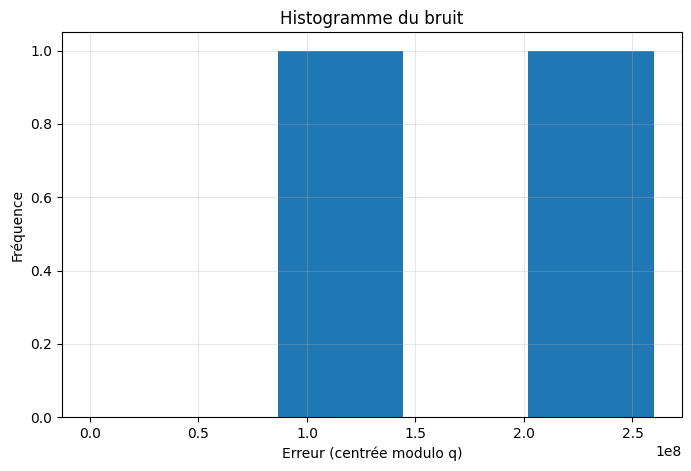

max noise: 0.001294258102485703


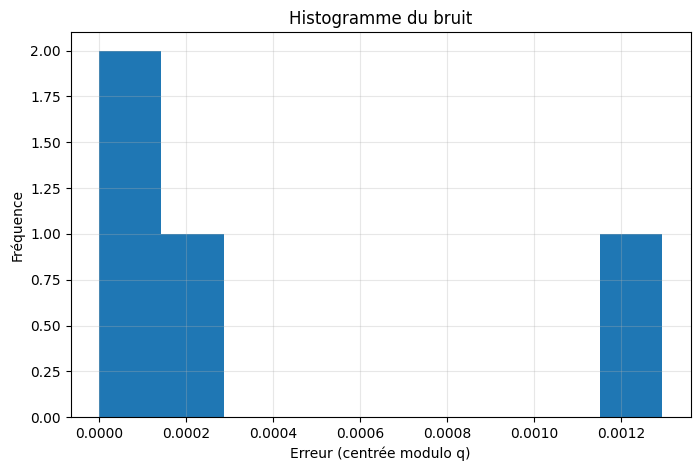

max noise: 1000013216.3250422


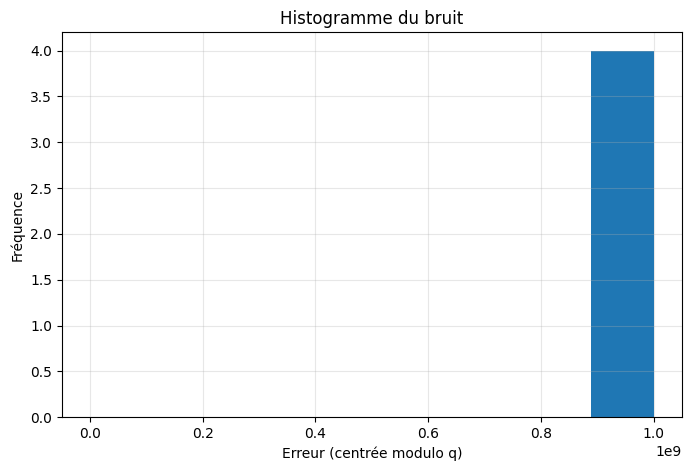

In [52]:
# Vérification des résultat 
mult_of_encoded_pltx = poly_mutl_mod(m_i, m_j, q)
mult_scaled_of_pltx =mod_for_arb_int(Delta*CKKS_Encoding((y_i * y_j), Delta), q)
mult_of_pltx_scaled =mod_for_arb_int(CKKS_Encoding((y_i * y_j), Delta), q)

mult_of_encr_decr_pltx = poly_mutl_mod(
    CKKS_Decryption(
        CKKS_Encryption(m_encoded=m_i,q=q,S=S),
        S=S, 
        Delta=Delta,
        q=q
    ), 
    CKKS_Decryption(
        CKKS_Encryption(m_encoded=m_j,q=q,S=S),
        S=S, 
        Delta=Delta,
        q=q
    ),
    q=q
) 
result_by_D = ((D_0 + poly_mutl_mod(D_1, S, q) + poly_mutl_mod(D_2, poly_mutl_mod(S, S, q), q)) % q)

print(
    f"{'Mult of ciphertexts':<32}: {result}\n\n"
    f"{'Encoded and scaled mult of pltx':<32}: {mult_scaled_of_pltx}\n\n"
    f"{'Mult of encoded pltxs':<32}: {mult_of_encoded_pltx}\n\n"
    f"{'Mult of Encr then Decr pltxs':<32}: {mult_of_encr_decr_pltx}\n\n"
    f"{'By D_2':<32}: {result_by_D}\n\n"
    f"{'Expected result' :<32} : {mult_of_pltx_scaled}"
)

# Show_encryption_impact(m=(mult_of_encoded_pltx), m_encr_decr=result, q=q)
Show_encryption_impact(m=(mult_of_encoded_pltx), m_encr_decr=result, q=q, in_percent=False)
Show_encryption_impact(m=(mult_of_encoded_pltx), m_encr_decr=result, q=q, in_percent=True)
Show_encryption_impact(m=(mult_of_pltx_scaled), m_encr_decr=result, q=q, in_percent=True)

Nous obtenons le bon résultat, mais nous devons le rescaled pour espérer obtenir le correct résultat lors du décodage. 

### Rescaling en pratique 

In [53]:
q_prime = q // Delta
Combine_cipher_rescaled = np.array([
    mod_for_arb_int((Combine_cipher[0] // Delta), q_prime), 
    mod_for_arb_int((Combine_cipher[1] // Delta), q_prime)
])
result_rescaled = CKKS_Decryption(Combine_cipher_rescaled, S, Delta, q_prime)

max noise: 0.001364796440610073


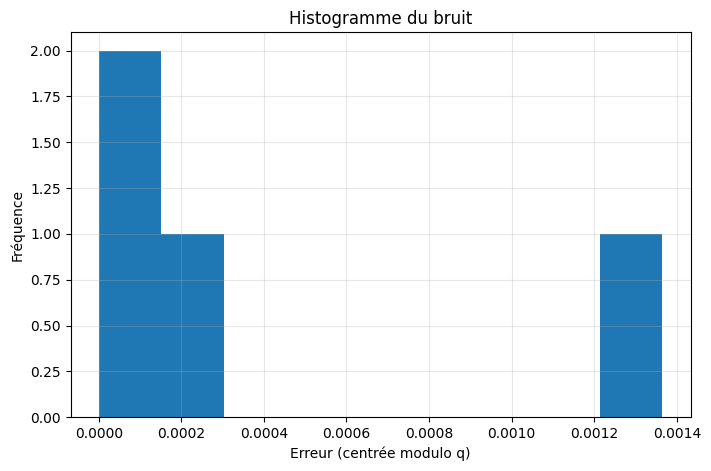

In [54]:
Show_encryption_impact(m=(mult_of_pltx_scaled), m_encr_decr=result_rescaled, q=q_prime, in_percent=True)

### Résultats 

Dans un premier temps nous pouvons comparer : 
$$\begin{array}{cc}
Decr \big( (D_1, D_0) + \langle Decomp^g(D_2), RLev^{\beta, \ell} (S^2) \rangle / \Delta \big) \\
= \Delta m_i m_j + (m_ie_j + m_je_i) + \frac{e_i e_j}{\Delta} \\
\approx \Delta m_i m_j
\end{array}
$$
et 

$$\begin{array}{cc}
Encoding(y_i \cdot y_j) = \Delta m_i m_j
\end{array}
$$


In [55]:
# Comparaison da la multiplication après scaling et déchiffrement avec la multiplication effectué avant l'encodage puis chiffré 
print(result_rescaled, mod_for_arb_int(CKKS_Encoding((y_i * y_j) , Delta), q_prime), "\n", sep="\n")

print(f"Différence entre la multiplication CKKS et la multiplication en clair : {np.abs(result_rescaled - mod_for_arb_int(CKKS_Encoding((y_i * y_j) , Delta), q_prime))}")

[1685256 10986086 22282726 13218400]
[1685233 10986078 22282740 13218427]


Différence entre la multiplication CKKS et la multiplication en clair : [23 8 14 27]


Enfin, nous pouvons comparer les résultats après décodage 

In [56]:
# Comparaison des deux résultats finaux 
CKKS_mult_decoded = CKKS_decoding(modulus_centering(result_rescaled, q_prime), Delta)

print(
    f"{'CKKS mult decoded':<19} : {CKKS_mult_decoded}\n"
    f"{'Expected result':<19} : {(y_i*y_j)}"
    )

# Erreur de précision 
print(f"{'Erreur de précision':<19} : {np.abs(CKKS_mult_decoded - (y_i*y_j))}")

CKKS mult decoded   : [(0.010677163286233249+3.939788218573486j) (0.3263740367137671-0.5167569814265147j)]
Expected result     : [0.0106724 +3.93979095j 0.32637425-0.51675714j]
Erreur de précision : [5.490639267543376e-06 2.662118890194183e-07]


Maintenant que nous avons un algorithme qui permet de faire un multiplication, nous pouvons tester d'ne faire un maximum. 

### Multiplication : wrap-up 

In [57]:
def CKKS_mutiplication(Encr_m_i, Encr_m_j, q, Delta, S): 

    # Calcul du premier ciphertext
    A_i, B_i = Encr_m_i[0], Encr_m_i[1]
    A_j, B_j = Encr_m_j[0], Encr_m_j[1]
    D_0 = (poly_mutl_mod(B_i, B_j, q))
    D_1 = mod_for_arb_int((poly_mutl_mod(A_i, B_j, q) + poly_mutl_mod(A_j, B_i, q)), q)
    first_ciph = np.array((D_1, D_0))

    n = len(A_i)

    # Calcul du second ciphertext
    D_2 = poly_mutl_mod(A_i, A_j, q)
    # Calcul des facteurs de décomposition en base Beta et au niveau l 
    decomp_factors_beta = []
    Beta = 2**16
    ell = q.bit_length() // 16
    for i in range (ell) : 
        decomp_factors_beta.append(int(round((Beta**(ell-(i+1))))))
    D_2_factors = compute_D_2_factors(D_2=D_2, decomp_factors_beta=decomp_factors_beta)

    # Chiffrement de S^2 avec le facteur de décomposition associé 
    list_of_S_2_Encr = []
    S2 = poly_mutl_mod(S, S, q)
    for i, decomp_factor in enumerate(decomp_factors_beta) :
        list_of_S_2_Encr.append(
            CKKS_Encryption(
                m_encoded= mod_for_arb_int(decomp_factor*S2, q),
                q = q, 
                S = S
            )
        )

    # Composition du deuxième ciphertext 
    second_cipher = np.array(
        [
            [0 for _ in range(n)],
            [0 for _ in range(n)]
        ],
        dtype=object
    )
    
    # POur chaque facteur decomposé D_2
    for i in range(ell): 
        # Pour chaque partie du ciphertext (soit A et B)
        for j in range(len(list_of_S_2_Encr[i])):
            second_cipher[j] += poly_mutl_mod(D_2_factors[i], list_of_S_2_Encr[i][j], q)

    second_cipher = np.array([
        mod_for_arb_int(second_cipher[0], q), 
        mod_for_arb_int(second_cipher[1], q)
        ]
    )

    # Combinaison des deux ciphertext en un
    Combine_cipher = np.array([
        mod_for_arb_int(first_ciph[0] + second_cipher[0], q), 
        mod_for_arb_int(first_ciph[1] + second_cipher[1], q), 
        ])

    #Rescaling
    q_prime = q // Delta
    Combine_cipher_rescaled = np.array([
        mod_for_arb_int((Combine_cipher[0] // Delta), q_prime), 
        mod_for_arb_int((Combine_cipher[1] // Delta), q_prime)
    ])

    return Combine_cipher_rescaled, q_prime

In [58]:
Combine_cipher_rescaled_by_func, q_prime_func = CKKS_mutiplication(
                Encr_m_i=Encr_m_i, 
                Encr_m_j=Encr_m_j,
                q=q, 
                Delta=Delta, 
                S=S
            )

CKKS_mult_func_decoded = CKKS_decoding(
    modulus_centering(
        CKKS_Decryption(
            Combine_cipher_rescaled_by_func,
            S=S, 
            Delta=Delta,
            q=q_prime_func
        ), q=q_prime_func
    ),Delta=Delta
)

In [59]:
print(
    f"{'CKKS mult decoded':<26} : {CKKS_mult_decoded}\n"
    f"{'CKKS mult function decoded':<26} : {CKKS_mult_func_decoded}\n"
    f"{'Expected result':<26} : {(y_i*y_j)}"
    )

# Erreur de précision 
print(f"{'Erreur de précision':<26} : {np.abs(CKKS_mult_func_decoded - (y_i*y_j))}")

CKKS mult decoded          : [(0.010677163286233249+3.939788218573486j) (0.3263740367137671-0.5167569814265147j)]
CKKS mult function decoded : [(0.010676846128945705+3.9397898256802666j) (0.3263731538710546-0.5167571743197337j)]
Expected result            : [0.0106724 +3.93979095j 0.32637425-0.51675714j]
Erreur de précision        : [4.585444973092531e-06 1.0952633370666516e-06]


In [60]:
#Test de multiples multiplication 
# # Création des messages
y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y_j = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y_k = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y_l = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]


# Encodage des messages
m_i = CKKS_Encoding(m=y_i, Delta=Delta)
m_j = CKKS_Encoding(m=y_j, Delta=Delta)
m_k = CKKS_Encoding(m=y_k, Delta=Delta)
m_l = CKKS_Encoding(m=y_l, Delta=Delta)

# Chiffrement des messages 
Encr_m_i = CKKS_Encryption(m_encoded=m_i, q=q, S=S)
Encr_m_j = CKKS_Encryption(m_encoded=m_j, q=q, S=S)
Encr_m_k = CKKS_Encryption(m_encoded=m_k, q=q, S=S)
Encr_m_l = CKKS_Encryption(m_encoded=m_l, q=q, S=S)

# Calcul de la mmultiplication dans les chiffrés 
Combine_cipher_rescaled_1_mult, q_prime_1_mult = CKKS_mutiplication(
                Encr_m_i=Encr_m_i, 
                Encr_m_j=Encr_m_j,
                q=q, 
                Delta=Delta, 
                S=S
            )

# Calcul de la mmultiplication dans les chiffrés 
Combine_cipher_rescaled_2_mult, q_prime_2_mult = CKKS_mutiplication(
                Encr_m_i=Combine_cipher_rescaled_1_mult, 
                Encr_m_j=Encr_m_k,
                q=q_prime_1_mult, # ? 
                Delta=Delta, 
                S=S
            )

# Calcul de la mmultiplication dans les chiffrés 
Combine_cipher_rescaled_3_mult, q_prime_3_mult = CKKS_mutiplication(
                Encr_m_i=Combine_cipher_rescaled_2_mult, 
                Encr_m_j=Encr_m_l,
                q=q_prime_2_mult, # ? 
                Delta=Delta, 
                S=S
            )


CKKS_mult_func_decoded = CKKS_decoding(
    modulus_centering(
        CKKS_Decryption(
            Combine_cipher_rescaled_3_mult,
            S=S, 
            Delta=Delta,
            q=q_prime_3_mult
        ), q=q_prime_3_mult
    ),Delta=Delta
)

expected_result = y_i*y_j*y_k*y_l

In [61]:
print(
    f"{'CKKS mult function decoded':<26} : {CKKS_mult_func_decoded}\n"
    f"{'Expected result':<26} : {expected_result}"
    )

# Erreur de précision 
print(f"{'Erreur de précision':<26} : {(CKKS_mult_func_decoded - expected_result)}")

CKKS mult function decoded : [(-4.095348027265052-6.638983070536513j) (0.7674472272650514-5.426307670536513j)]
Expected result            : [-4.09535347-6.63898661j  0.76745518-5.42629651j]
Erreur de précision        : [(5.447728565144416e-06+3.543704147901394e-06j) (-7.957134333547167e-06-1.115880087354526e-05j)]


In [62]:
list_of_inputs = []
list_of_encrypted_inputs = []
nb_mult = 300
for i in range(nb_mult): 
    y = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
    list_of_inputs.append(y)
    list_of_encrypted_inputs.append(
        CKKS_Encryption(
            m_encoded=CKKS_Encoding(
                m=y, Delta=Delta, q=q
            ), q=q, S=S
        )
    )

In [63]:
intial_combine_cipher = list_of_encrypted_inputs[-1]
q_for_mult = q
for i in range(nb_mult-1):
    print(i)
    combine_cipher_final, q_prime_final = CKKS_mutiplication(
                Encr_m_i=intial_combine_cipher, 
                Encr_m_j=list_of_encrypted_inputs[i],
                q=q_for_mult, 
                Delta=Delta, 
                S=S
            )
    q_for_mult = q_prime_final
    intial_combine_cipher = combine_cipher_final

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [64]:
CKKS_mult_func_decoded = CKKS_decoding(
    modulus_centering(
        CKKS_Decryption(
            combine_cipher_final,
            S=S, 
            Delta=Delta,
            q=q_prime_final
        ), q=q_prime_final
    ),Delta=Delta
)

expected_result = 1
for i in range(nb_mult): 
    expected_result = expected_result * list_of_inputs[i]



In [65]:
print(
    f"{'CKKS mult function decoded':<26} : {CKKS_mult_func_decoded}\n"
    f"{'Expected result':<26} : {expected_result}"
    )

erreur_precision = (CKKS_mult_func_decoded - expected_result)
error_real_part = np.array([z.real for z in erreur_precision])
error_imag_part = np.array([z.imag for z in erreur_precision])

print(
    f"{'Erreur de précision':<26} : {erreur_precision}\n"
    f"Erreur de précision (%)\n"
    f"{'Partie réelle':<26} : {error_real_part * 100 / np.abs(expected_result.real)} (%)\n"
    f"{'Partie imaginaire':<26} : {error_imag_part * 100 / np.abs(expected_result.imag)} (%)"
)

CKKS mult function decoded : [(-1.161097673267389e+64+8.340868532057602e+63j) (9.254864829848828e+61+7.552627687583381e+61j)]
Expected result            : [-1.16109769e+64+8.34115298e+63j  9.25574847e+61+7.55266519e+61j]
Erreur de précision        : [(2.1140138157700373e+56-2.8444866327823665e+59j) (-8.836376806026239e+57-3.7506993826988943e+56j)]
Erreur de précision (%)
Partie réelle              : [ 1.82070279e-06 -9.54690681e-03] (%)
Partie imaginaire          : [-0.00341018 -0.00049661] (%)
